# **TAS (Tele Assistance System) Dimensional Analysis Modelling**
NOTE: _[DASA CASE STUDY 1]_

## **Summary**

This notebook is focused on three main objectives:
1. summarizing the key aspects of the Tele Assistance System (TAS) architecture and its adaptive capabilities in the context of telehealth services for chronic patients.
2. Modelling the TAS architecture using appropriate design notations and tools to visualize its components and interactions.
3. Simulating the TAS behavior under different scenarios to evaluate its performance and adaptability with Queue Network (QN) models.

The results will be used to evaluate the Dimensional Analysis for CUSTOM Architecture (DASA) methodology, its CUSTOM tool (PyDASA) and its effectiveness in modelling and Quality Scenarios (QS) trade-off in self-adaptive-systems (SAS).

---

## **Software Architecture**
- TAS (Tele Assistance System) operates in a dynamic environment where service quality, availability, and user needs frequently change.
- The TAS is further subdivided into Controller and Target System subsystem components.
- The Controller is responsible for managing the overall system behavior, while the Target System focuses on executing specific tasks related to patient care.
- The TAS target systems follows a Service-oriented architecture (SOA) pattern.
- The TAS Controller follows a MAPE-K (Monitor-Analyze-Plan-Execute-Knowledge) feedback loop for self-adaptation.
- Adaptations focus on maintaining **reliability**, **performance**, and **compliance** with patient care standards (5 specific scenarios).
- ActivFORMS provides the runtime framework for model-based adaptation using runtime models, simulations, and verified decision-making.

---

_**NOTE: MORE DETAILS ON THE ARCHITECTURE IN THE ANALYTICAL MODELLING NOTEBOOK!.**_

---

## **Code**

_**SUMMARY:**_

This code is for the analytical solution of the Case Study (TAS) Dimensional Analysis Model and is structured as follows:
1. Analytical Dimensional Model (DA).
2. Importing necessary libraries and modules.
3. Loading DA default configuration.
4. Solving the DA analytically.
5. Solving the DA with Monte Carlo simulations.
6. Plotting the DA with the obtained metrics.
7. Loading DA 'optimal' configuration.
8. Solving the DA optimally.
9. Simulating the DA with the 'optimal' configuration.
10. Plotting the optimal DA with the obtained metrics.
11. Saving the results.
12. Comparing the analytical results (Default Vs. Optimal)
13. Visualizing the results.
14. Generating a summary report.

## **Target System Queue Network Model**

<svg viewBox="0 0 4650 2000" width="1400" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/04A - Queue Network.svg" alt="queue-net-diagram" />
    <div align="center"><em>Image 4. TAS Queue Network Diagram.</em></div>
</svg>

### **Necessary Imports**

In [ ]:
# -*- coding: utf-8 -*-
# Native imports
import os
import re
import sys
import time
import gc
from typing import Union

# Third-party imports, data and numeric
import numpy as np
import pandas as pd

# Model Aprox + Visualizartion libraries
from scipy.interpolate import Rbf
from scipy.interpolate import griddata, LinearNDInterpolator
# from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import GradientBoostingRegressor

import matplotlib.pyplot as plt

# TODO remove all unused imports later
# # import qimensional model libraries PyDASA
# # config module
# from pydasa.utils import config
# # FDU modules
# from pydasa.core.fundamental import Dimension
# # FDU regex management
# from pydasa.dimensional.framework import DimSchema
# # Variable and Variable modules
# from pydasa.core.parameter import Variable
# # Dimensional Matrix Modelling module
# from pydasa.dimensional.model import DimMatrix
# # sensitivity analysis modules
# from pydasa.analysis.scenario import DimSensitivity
# from pydasa.handlers.influence import SensitivityHandler
# # Monte Carlo Simulation modules
# from pydasa.analysis.simulation import MonteCarloSim
# from pydasa.handlers.practical import MonteCarloHandler

# import queue network + models packages
from src.model.queueing import Queue
from src.model.analytical import solve_jackson_network, calculate_net_metrics

# import plot functions + grahics
from src.view.plots import plot_performance_coef_chart
from src.view.plots import plot_experiment_coef_chart
from src.view.plots import plot_coef_histograms

In [2]:
# cleaning memory
gc.collect()

40

### **Function Definitions**

In [3]:
# Simple formatter for console output
def fmt(val: Union[int, float, np.number]) -> Union[str, np.ndarray]:
    """Format a number to 4 decimal places for console output.

    Args:
        val (Union[int, float, np.number, np.ndarray]): The value to format.

    Returns:
        Union[str, np.ndarray]: The formatted value as a string or an array of strings.
    """
    if isinstance(val, (int, float, np.number)):
        if np.isnan(val) or np.isinf(val):
            return str(val)
        return f"{val:.4f}"
    elif isinstance(val, np.ndarray):
        return np.array([fmt(x) for x in val])
    return val

In [4]:
# Load configuration from a CSV file
def load(path: str, fname: str) -> pd.DataFrame:
    """Load configuration from a CSV file.

    Args:
        path (str): The directory path where the CSV file is located.
        fname (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: A DataFrame containing the configuration data.
            CSV format:
                - node: <node_id>
                - miu: <mean_service_time>
                - c: <service_channels>
                - K: <buffer_capacity | max_queue_length>
                - lambda0: <initial_arrival_rate>
                - L0: <initial_queue_length>
                - pm: <matrix_routing_probabilities>
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Loading configuration from: {_file_path}")
    df = pd.read_csv(_file_path, encoding="utf-8")
    
    # # Escape single backslashes in all string columns
    # for col in df.select_dtypes(include='object').columns:
    #     df[col] = df[col].str.replace(r"\\", r"\\\\", regex=True)
    return df

In [5]:
# save dataframes in CSV files
def save(path: str, fname: str, data: pd.DataFrame) -> None:
    """Save a DataFrame to a CSV file.

    Args:
        path (str): The directory path where the CSV file will be saved.
        fname (str): The name of the CSV file to save.
        data (pd.DataFrame): The DataFrame containing the data to save.
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Saving data to: {_file_path}")
    data.to_csv(_file_path, index=False, encoding="utf-8")

In [6]:
# calculate queue length, with ququeing theory formulas
def queue_length(lambda_z: float,
                 mu: float,
                 c: int,
                 K: int) -> float:
    """Calculate the average queue length (Lq) for an M/M/c/K queueing system.

    Args:
        lambda_z (float): The arrival rate (λ).
        mu (float): The service rate (μ).
        c (int): The number of service channels.
        K (int): The maximum number of customers in the system.

    Returns:
        float: The average number of requests in the system (L, Lq).
    """
    adjusted = False

    # to avoid unstable system
    if lambda_z >= mu * c * 0.95:
        lambda_z = mu * c * 0.95
        adjusted = True

    # create queue object
    q = Queue("M/M/s/K", lambda_z, mu, c, K)
    # calculate queue metrics
    q.calculate_metrics()
    ans = q.avg_len

    # to know afterwars what data is adjusted in df
    if adjusted is True:
        # ans = -1 * ans
        ans = (lambda_z, mu, c, K, ans)
    # print(f"lambda_z: {lambda_z}, mu: {mu}, c: {c}, K: {K}, L/Lq: {ans}")
    # check the results in the dataframe afterwars
    return ans

In [7]:
# calculate queue time, with Little's Law
def queue_time(lambda_z: float, len_queue: float) -> float:
    """Calculate the average time in the queue system (W, Wq).

    Args:
        len_queue (float): The average queue length (L, Lq).
        lambda_z (float): The arrival rate (λ).

    Returns:
        float: The average wait time in the queue (W, Wq).
    """
    if lambda_z == 0:
        return float("inf")  # Avoid division by zero

    wait_time = len_queue / lambda_z
    # print(f"lambda_z: {lambda_z}, L/Lq: {len_queue}, W: {wait_time}")
    return wait_time

In [8]:
def adjust_rate(rate:float, err:float=0.0) -> float:
    """Adjust the arrival rate by a given error percentage.

    Args:
        rate (float): The original arrival rate (λ).
        err (float): The error percentage to adjust the rate by.

    Returns:
        float: The adjusted arrival rate otherwise known as departure rate (x).
    """
    adjusted_rate = rate * (1 + err)
    return adjusted_rate

In [9]:
def uniform_int(low: int, high: int) -> int:
    """Generate a random integer within a specified range.

    Args:
        low (int): The lower bound of the range (inclusive).
        high (int): The upper bound of the range (exclusive).

    Returns:
        int: A random integer between low and high.
    """
    return np.random.randint(low, high)

In [10]:
def shifted_uniform_int(low: int, high: int, shift: int) -> int:
    """Generate a random integer within a specified range and apply a shift.

    Args:
        low (int): The lower bound of the range (inclusive).
        high (int): The upper bound of the range (exclusive).
        shift (int): The value to shift the generated number by.

    Returns:
        int: A random integer between low and high, shifted by the specified amount.
    """
    return np.random.randint(low, high) + shift

In [11]:
def uniform(low: float, high: float) -> float:
    """Generate a random float within a specified range.

    Args:
        low (float): The lower bound of the range (inclusive).
        high (float): The upper bound of the range (exclusive).

    Returns:
        float: A random float between low and high.
    """
    return np.random.uniform(low, high)

In [12]:
def create_dimensional_groups(config: pd.DataFrame,
                              verbose: bool = False) -> dict:
    """Create dimensional variable groups from the default configuration.

    Args:
        config (pd.DataFrame): The configuration DataFrame.
        verbose (bool, optional): Whether to print detailed information. Defaults to False.

    Returns:
        dict: A dictionary containing groups of dimensional variables.
    """
    # create a dimensional set of variables from config file
    # dimensional groups dictionary
    dim_groups = {}
    
    # unique dimensional matrix
    unique_dim_groups = config["dm"].unique().tolist()
    for group in unique_dim_groups:
        _tdict = dict()
        # filter by dimensional matrix number
        _relevance_lt = config[config["dm"] == group]
        # filter by relevant attributes
        _relevance_lt = _relevance_lt[_relevance_lt["dm"] == group]
        if verbose:
            _msg = f"Dimensional Matrix: {group}, "
            _msg += f"with {_relevance_lt.shape[0]} relevant vars."
            print(_msg)

        # create variable instances
        for var in _relevance_lt.to_dict(orient="records"):
            key = var["_sym"]
            # remove unnecessary keys
            var.pop("dm", None)

            # cast internal dict column for dist_params
            if var.get("_dist_params") is not None:
                s = var.get("_dist_params")
                # s = r"".join(s)
                s = s.replace("\\", "\\\\")
                data = eval(s)
                dt = {"_dist_params": data}
                var.update(dt)

            # cast internal dict column for dependences
            if var.get("_depends") is not None:
                s = var.get("_depends")
                # s = r"".join(s)
                s = s.replace("\\", "\\\\")
                data = eval(s)
                dt = {"_depends": data}
                var.update(dt)
            # create variable instance
            _tdict[key] = Variable(**var)
            if verbose:
                _msg = f"\tCreated Variable Instance: {key}: {_tdict[key]}"
                print(_msg)

        # add to dictionary
        dim_groups[group] = _tdict

    return dim_groups

In [13]:
def configure_dimensional_dist(dim_groups: dict,
                               verbose: bool = False) -> dict:
    """Configure dimensional variable distributions for a specific group.

    Args:
        dim_groups (dict): A dictionary containing the groups of dimensional variables.
        verbose (bool, optional): Whether to print detailed information. Defaults to False.

    Returns:
        dict: A dictionary containing the dimensional group with configured distribution functions in its variables.
    """

    # select the dimensional group to configure
    # im tired so lambda functions are in order
    for dm in dim_groups.keys():
        for key, var in dim_groups[dm].items():
            # if the dist is uniform for discrete vals like c's and K's
            if var._dist_type == "uniform_int":
                _low = var._dist_params.get("low")  # Default if missing
                _high = var._dist_params.get("high")  # Default if missing

                # Use default parameter capture to correctly bind values
                _foo = lambda l=_low, h=_high: np.random.randint(l, h)
                var._dist_func = _foo

            # if the dist is shifted uniform for discrete vals like c's + K's
            if var._dist_type == "shifted_uniform_int":
                _low = var._dist_params.get("low")
                _high = var._dist_params.get("high")

                # b is fixed shift value
                # Use default parameter capture to correctly bind values
                _foo = lambda b, l=_low, h=_high: b + np.random.randint(l, h)
                var._dist_func = _foo

            # if the dist is uniform for continuous vals like miu's and lambda's
            if var._dist_type == "uniform":
                _low = var._dist_params.get("low")
                _high = var._dist_params.get("high")
                _foo = lambda l=_low, h=_high: np.random.uniform(l, h)
                var._dist_func = _foo

            # if there is an error probability its the random multiplied by the error rate
            if var._dist_type == "adjusted_uniform":
                _error = var._dist_params.get("constant")
                _foo = lambda error=_error: np.random.rand() * error
                var._dist_func = _foo

            # with exponential distribution
            if var._dist_type == "exponential":
                _scale = var._dist_params.get("scale")
                var._dist_func = lambda s=_scale:  np.random.exponential(s)

            # if the dist is constant, like the error in the queue model
            if var._dist_type == "constant":
                _constant = var._dist_params.get("constant")
                var._dist_func = lambda cst=_constant: cst

            # if the dist is adjusted uniform for continous vals like chi's = lambda's * (1 - x%)
            if var._dist_type == "adjusted_rate":
                var._dist_func = lambda rate, err: adjust_rate(rate, err)

            # if the dist is a queue theory formula
            if var._dist_type == "queue_length":
                _foo = lambda la_z, mu, c, K: queue_length(la_z, mu, c, K)
                var._dist_func = _foo

            if var._dist_type == "queue_time":
                var._dist_func = lambda La_z, lq: queue_time(La_z, lq)

            if verbose:
                _msg = f"\tConfigured Variable: {key}: {var.sym}"
                print(_msg)
    return dim_groups

In [14]:
def  configure_dimensional_range(dim_groups: dict,
                                 range_df: pd.DataFrame,
                                 verbose: bool = False) -> dict:

    for dm in dim_groups.keys():
        if verbose:
            print(f"Configuring range for Dimensional Matrix: {dm}")
        for key, var in dim_groups[dm].items():
            # print(f"Configuring range for variable: {key}")
            if key in range_df.columns:
                # print(f"Found range data for variable: {key}")
                data_range = range_df[key]
                # print(data_range.shape)
                data_range = data_range.values.flatten().tolist()
                # print(f"Data Range Values for {key}: {data_range}")
                var._std_range = np.array(data_range)
            if verbose:
                _msg = f"\tConfigured Variable: {key}: {type(var)}"
                print(f"var range size: {var._std_range.shape}")
                print(_msg)
    return dim_groups

In [15]:
def create_dimensional_matrix(config: pd.DataFrame,
                              dim_groups: dict,
                              framework: str,
                              dim_scheme: DimSchema,
                              verbose: bool = False) -> dict:
    dimensional_model_groups = {}
    for group in config["dm"].unique().tolist():
        group_vars = dim_groups[group]
        if verbose:
            _msg = f"Dimensional Matrix: {group}, "
            _msg += f"with {len(group_vars)} variables."
            print(_msg)
        _descript = f"TAS Dimensional Matrix {group}"
        dimensional_model_groups[group] = DimMatrix(_fwk=framework,
                                                    _idx=group,
                                                    _framework=dim_scheme,
                                                    description=_descript)
        # setting Dimensional Model variables
        dimensional_model_groups[group].variables = group_vars
        # setting Dimensional Model relevance list
        dimensional_model_groups[group].relevant_lt = group_vars
        if verbose:
            n_vars = len(dimensional_model_groups[group].variables)
            n_relev = len(dimensional_model_groups[group].relevant_lt)
            _msg = f"\tDimensional Matrix {group} with {n_vars} variables, "
            _msg += f"and {n_relev} relevant variables."
            print(_msg)
    return dimensional_model_groups

In [16]:
def solve_dimensional_model(model_groups: dict,
                            verbose: bool = False,
                            details: bool = False) -> dict:

    # solving each dimensional model
    for group, model in model_groups.items():
        # Here you would implement the logic to solve the dimensional model

        model.create_matrix()
        model.solve_matrix()

        if verbose:
            _msg = f"\tDimensional Matrix/Model ID: {group}, "
            _msg += f"with No. Coefficients: {len(model.coefficients)}"
            print(_msg)
            print("\tCreating Matrix for Dimensional Model...")
            print("\tSolving Matrix for Dimensional Model...")
            print(f"\tFinished Solving Dimensional Model: {group}")

        # display model coefficients details
        if details:
            print(f"\tModel {group}, Coefficients Details:")
            for k, v in model.coefficients.items():
                print(f"\t\t'{k}': {fmt(v.pi_expr)}, [{v.var_dims}]")
            print()
    # returning the solved model groups
    return model_groups

In [17]:
def create_sensitivity_analysis(model_groups: dict) -> dict:
    """Create sensitivity analysis for each dimensional model group.

    Args:
        model_groups (dict): A dictionary containing the groups of dimensional models.

    Returns:
        dict: A dictionary containing the sensitivity analysis results for each model group.
    """

    sensitivity_groups = {}
    # creating sensitivity groups
    for group, models in model_groups.items():
        # add sensitivity analysis handler for each model group
        sensitivity_groups[group] = SensitivityHandler(
            _idx=group,
            _sym=f"$SA_{{TAS_{group}}}$",
            name=f"Sensitivity Analysis for TAS DM {group}",
            description=f"Sensitivity Analysis for Dimensional Model: {group}.",
            _variables=model_groups[group].variables,
            _coefficients=model_groups[group].coefficients,
        )
    # Return the sensitivity analysis results for each model group
    return sensitivity_groups

In [18]:
def execute_sensitivity_analysis(sens_groups: dict,
                                 vtype: str = None,
                                 n_samples: int = 0,
                                 verbose: bool = False,
                                 details: bool = False) -> dict:

    # executing sensitivity analysis for each sensitivity group
    for group, sens in sens_groups.items():
        if verbose:
            _msg = f"\tExecuting Sensitivity Analysis for Group: {group}."
            _msg += f"with {len(sens.variables)} variables."
            print(_msg)

        # perform symbolic sensitivity analysis
        if vtype is not None:
            if details:
                _msg = f"\tExecuting symbolic analysis for '{vtype}' "
                _msg += f"variables in group: {group}."
                print(_msg)
            sens.analyze_symbolic(val_type=vtype)

        # perform numeric sensitivity analysis
        if n_samples > 0:
            if details:
                _msg = f"\tExecuting numeric analysis with {n_samples} samples "
                _msg += f"in group: {group}."
                print(_msg)
            sens.analyze_numeric(n_samples=n_samples)
        if verbose:
            print(f"\tFinished Sensitivity Analysis for Group: {group}.")
    return sens_groups

In [19]:
def create_monte_carlo_simulation(model_groups: dict,
                                  n_experiments: int = 1000,
                                  verbose: bool = False) -> dict:
    """Create Monte Carlo simulation for each dimensional model group.

    Args:
        model_groups (dict): A dictionary containing the groups of dimensional models.
        n_experiments (int, optional): The number of experiments to run. Defaults to 1000.
        verbose (bool, optional): Whether to print detailed information. Defaults to False.

    Returns:
        dict: A dictionary containing the Monte Carlo simulation results for each model group.
    """

    simulation_groups = {}
    # creating simulation groups
    for group, models in model_groups.items():
        # add monte carlo simulation handler for each model group
        simulation_groups[group] = MonteCarloHandler(
            _idx=group,
            _sym=f"$MCS_{{TAS_{group}}}$",
            name=f"Monte Carlo Simulation for TAS DM {group}",
            description=f"Monte Carlo Simulation for Dimensional Model: {group}.",
            _variables=models.variables,
            _coefficients=models.coefficients,
            _experiments=n_experiments,
        )
        if verbose:
            _msg = f"\tCreated Monte Carlo Simulation for Group: {group}."
            _msg += f"with {len(models.variables)} variables."
            print(_msg)

    # Return the monte carlo simulation results for each model group
    return simulation_groups

In [20]:
def execute_monte_carlo(mc_groups: dict,
                        n_samples: int = 1000,
                        verbose: bool = False) -> dict:
    """Execute Monte Carlo simulation for each dimensional model group.

    Args:
        mc_groups (dict): A dictionary containing the groups of Monte Carlo simulations.
        n_experiments (int, optional): The number of experiments to run. Defaults to 1000.
        verbose (bool, optional): Whether to print detailed information. Defaults to False.

    Returns:
        dict: A dictionary containing the results of the Monte Carlo simulations for each model group.
    """

    # executing monte carlo simulation for each simulation group
    for group, mc_handler in mc_groups.items():
        if verbose:
            _msg = f"\tExecuting Monte Carlo Simulation for Group: {group} "
            _msg += f"with {len(mc_handler.variables)} variables."
            print(_msg)

        # configure distributions and simulations
        mc_handler._config_distributions()
        mc_handler._config_simulations()
        # perform monte carlo simulation
        mc_handler.simulate(n_samples=n_samples)

        mc_groups[group] = mc_handler
        if verbose:
            print(f"\tFinished Monte Carlo Simulation for Group: {group}.")
    return mc_groups

In [21]:
def process_monte_carlo_results(simulation_groups: dict,
                                verbose: bool = False) -> tuple:
    """Post-process Monte Carlo simulation results for each dimensional model group.

    Args:
        simulation_groups (dict): A dictionary containing the groups of Monte Carlo simulations.

    Returns:
        dict: A dictionary containing the post-processed results for each group.
    """
    # coefficient global index
    i = 0

    # records for the unifided simulation dataframe
    records = {}

    # simulation results statistics
    statistics = []

    # global coefficient name = coefficient formula
    coefs = {}

    for group, sim in simulation_groups.items():
        if verbose:
            _msg = f"\tPost-Processing Monte Carlo Results for Group: {group}, "
            _msg += f"with {len(sim.variables)} variables, "
            _msg += f"and {sim._experiments} iterations."
            print(_msg)
            _msg = f"\tVariables: {list(sim.variables.keys())}, "
            _msg += f"No. Coefficients: {len(sim.coefficients)}"
        for j, (pi, coef) in enumerate(sim.coefficients.items()):
            # getting the coefficient data
            if verbose:
                _msg = f"\t\tProcessing Coefficient: {coef.name}: {pi} "
                _msg += f"= {coef.pi_expr}"
                print(_msg)
                _msg = f"\t\tGlobal Idx: {i}, Local Idx: {j}, "
                _msg += f"Inputs := {list(coef.var_dims.keys())}, "
                _msg += f"Size: {len(coef.var_dims)}"
                print(_msg)

            # rename Pi for DataFrame column with global idx
            pi_rename = str(pi)
            pi_rename = pi_rename.replace(str(j), str(i))
            if verbose:
                _msg = f"\t\tRenaming Coef. FROM: {pi} TO: {pi_rename}"
                print(_msg)
            
            coefs[pi_rename] = coef.pi_expr

            # get simulation results
            simulations = sim.get_simulation(pi)
            # print(type(simulations))
            if simulations:

                # exporting results
                results = simulations.extract_results()

                # rename keys in results dict
                for key in list(results.keys()):
                    new_key = key.replace(pi, pi_rename)
                    results[new_key] = results.pop(key)
                
                records.update(results)

                # exporting statistics
                stats = {
                    "name": pi_rename,
                    "coef": coef.pi_expr
                }
                # update with simulation statistics
                stats.update(simulations.statistics)
                # add to statistics list
                statistics.append(stats)
            # updating global idx
            i += 1
        if verbose:
            _msg = f"\tFinished Post-Processing Coefficients Group: {group}.\n"
            print(_msg)

    # creating DataFrame for records and statistics
    records = pd.DataFrame(records)
    statistics = pd.DataFrame(statistics)

    return records, statistics, coefs

In [22]:
def consolidate_simulation_results(coefficient_groups: pd.DataFrame,
                                   columns: list,
                                   verbose: bool = False,
                                   details: bool = False) -> pd.DataFrame:
    """Consolidate simulation results from multiple coefficient groups.

    Args:
        coefficient_groups (pd.DataFrame): A DataFrame containing the simulation results for different coefficient groups.
        columns (list): A list of column names to process.
        verbose (bool, optional): If True, print detailed processing information. Defaults to False.
        details (bool, optional): If True, print additional details about the processing. Defaults to False.

    Returns:
        pd.DataFrame: A DataFrame containing the consolidated simulation results.
    """
    records = {}
    for i, col in enumerate(columns):
        if verbose:
            print(f"\tProcessing Column {i+1}/{len(columns)}: {col}")
        # iterate over the pi dataframe columns
        for j in range(i, coefficient_groups.shape[1], len(columns)):
            # check if the formula matches
            key = coefficient_groups.columns[j]
            val = coefficient_groups[key].values
            # if the column name is new, add it
            if col not in records:
                records[col] = val
                if details:
                    print(f"\t\tAdding New Column: {key}")
            # if the column name already exists, append data
            elif col in records:
                records[col] = np.concatenate(([records[col], val]))
        if verbose:
            print(f"\tFinished Processing Column: {col}\n")

    if details:
        print("Consolidated Records Summary:")
        for k, v in records.items():
            print(f"\t{k}: {len(v)}")

    return pd.DataFrame(records)

In [23]:
# path = os.path.dirname(__file__)\
PATH = os.getcwd()
print(f"Notebook path: {PATH}")

Notebook path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies


In [24]:
# Folder names
config_folder = "config"
test_folder = "tests"
calib_folder = "calibration"
docs_folder = "docs"
img_folder = "img"
data_folder = "data"
report_folder = "reports"
results_folder = "results"
cs_folder = "cs1"

In [25]:
# setting case study config folder
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         data_folder,
                         config_folder,
                         cs_folder)
print(f"Case Study Configuration path: {file_path}")

Case Study Configuration path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\data\config\cs1


### **Queue Model**
#### **Creating Dimensionless Charts**

##### **FDUs (Fundamental Design Units)**

In [26]:
# setting up custom FDU for CUSTOM architecture
tas_fwk = "SOFTWARE"
tas_scm = DimSchema(_sym="FDU_{TAS}",
                    _alias="fdu_tas",
                    _idx=0,
                    name="TAS FDUs",
                    _fwk=tas_fwk,
                    description="FDU schema for the TAS case study.")
# print(tas_scm)
print("=== TAS Fundamental Dimenional Unit (FDU) Schema ===")
for dim in tas_scm.fdu_lt:
    print(f"\t'{dim.sym}': {dim.name}, [{dim.unit}]")

=== TAS Fundamental Dimenional Unit (FDU) Schema ===
	'T': Time, [s]
	'D': Data, [bit]
	'E': Effort, [req]
	'C': Connectivity, [node]
	'A': Capacity, [process]


In [27]:
tas_fwk = "CUSTOM"
fdu_lt = [
    {
        "_idx": 0,
        "_sym": "T",
        "_fwk": tas_fwk,
        "description": "Duration of an event or interval.",
        "_unit": "s",
        "name": "Time",
        },
    {
        "_idx": 1,
        "_sym": "E",
        "_fwk": tas_fwk,
        "description": "Computational unit of effort to process a requests.",
        "_unit": "req",
        "name": "Effort",
        },
    {
        "_idx": 2,
        "_sym": "D",
        "_fwk": tas_fwk,
        "description": "Information processed by a component.",
        "_unit": "bit",
        "name": "Data",
    },
]
tas_scm = DimSchema(_sym="FDU_{Custom TAS}",
                    _alias="fdu_custom_tas",
                    _idx=0,
                    name="Custom TAS FDUs",
                    _fdu_lt=fdu_lt,
                    _fwk=tas_fwk,
                    description="Minimal FDU schema for TAS case study.")

# print(tas_scm)
print("=== TAS Fundamental Dimensional Unit (FDU) Schema ===")
for dim in tas_scm.fdu_lt:
    print(f"\t'{dim.sym}': {dim.name}, [{dim.unit}]")

=== TAS Fundamental Dimensional Unit (FDU) Schema ===
	'T': Time, [s]
	'E': Effort, [req]
	'D': Data, [bit]


In [28]:
tas_scm.update_global_config()
print("---- Checking Schema Regex ----")
print("\tWKNG_DFLT_FDU_PREC_LT:", config.WKNG_FDU_PREC_LT)
print("\tWKNG_FDU_RE:", config.WKNG_FDU_RE)
print("\tWKNG_POW_RE:", config.WKNG_POW_RE)
print("\tWKNG_NO_POW_RE:", config.WKNG_NO_POW_RE)
print("\tWKNG_FDU_SYM_RE:", config.WKNG_FDU_SYM_RE)

---- Checking Schema Regex ----
	WKNG_DFLT_FDU_PREC_LT: ['T', 'E', 'D']
	WKNG_FDU_RE: ^[TED](\^-?\d+)?(\*[TED](?:\^-?\d+)?)*$
	WKNG_POW_RE: \-?\d+
	WKNG_NO_POW_RE: [TED](?!\^)
	WKNG_FDU_SYM_RE: [TED]


In [29]:
print("---- Config Sensitivity & Monte Carlo Samples ----")
n_sens = 100
n_exp = 152
print(f"\tSensitivity Analysis Samples: {n_sens}")
print(f"\tMonte Carlo Simulation Samples: {n_exp}")

---- Config Sensitivity & Monte Carlo Samples ----
	Sensitivity Analysis Samples: 100
	Monte Carlo Simulation Samples: 152


In [30]:
file_path

'c:\\Users\\Felipe\\OneDrive\\Documents\\GitHub\\DASA-Design\\PyDASA-Case-Studies\\tests\\calibration\\data\\config\\cs1'

##### **Base Configuration**

In [31]:
# Load configuration with mixed queue models
dflt_qn_cfg = load(file_path, "dflt_calib_qn_model.csv")
print("Queue Network Configuration:")
dflt_qn_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\data\config\cs1\dflt_calib_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.33,0.33,0.33,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.33,0.33,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [32]:
# Load configuration with mixed queue models
dflt_da_cfg = load(file_path, "dflt_calib_dim_variables.csv")
print("Dimension Variables Configuration:")
dflt_da_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\data\config\cs1\dflt_calib_dim_variables.csv
Dimension Variables Configuration:


,_idx,dm,_sym,_alias,_fwk,name,description,relevant,_cat,_dims,...,_min,_max,_mean,_std_units,_std_min,_std_max,_std_mean,_dist_type,_depends,_dist_params
0,1,1,\lambda_{1},lambda_tas_1,CUSTOM,TAS 1 arrival rate,Arrival rate for TAS 1,True,IN,E*T^-1,...,34.5,655.5,345,req/s,34.5,655.5,345.0,uniform,[],"{'low': 34.5, 'high': 655.5}"
1,2,1,\mu_{1},mu_tas_1,CUSTOM,TAS 1 service rate,Service rate for TAS 1,True,CTRL,E*T^-1,...,90,1710,900,req/s,90.0,1710.0,900.0,uniform,[],"{'low': 90, 'high': 1710}"
2,3,1,err_{1},err_tas_1,CUSTOM,TAS 1 error probability,Service error probability for TAS 1,False,CTRL,E*T^-1,...,0.00%,0.00%,0,n.a.,0.0,0.0,0.0,adjusted_uniform,[],{'constant': 0}
3,4,1,\chi_{1},chi_tas_1,CUSTOM,TAS 1 departure rate,Departure rate for TAS 1,True,CTRL,E*T^-1,...,34.5,655.5,345,req/s,34.5,655.5,345.0,adjusted_rate,"['\lambda_{1}' , 'err_{1}']",{}
4,5,1,c_{1},c_tas_1,CUSTOM,TAS 1 resourses,Number of resources allocated in TAS 1,True,IN,E,...,1,3,2,req,1.0,3.0,2.0,uniform_int,[],"{'low': 1, 'high': 3}"


In [33]:
# setting case study data folder
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Configuration file path: {file_path}")

Configuration file path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\data


In [34]:
dflt_qn_data = load(file_path, "dflt_calib_analytical_net_metrics.csv")
print("Dimension Variables Data Range:")
dflt_qn_data.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\data\dflt_calib_analytical_net_metrics.csv
Dimension Variables Data Range:


,\lambda_{1},\mu_{1},\rho_{1},L_{1},Lq_{1},W_{1},Wq_{1},\lambda_{2},\mu_{2},\rho_{2},...,Lq_{12},W_{12},Wq_{12},\lambda_{13},\mu_{13},\rho_{13},L_{13},Lq_{13},W_{13},Wq_{13}
0,345.0,900.0,0.383333,0.621333,0.238016,0.001801,0.000690,258.75,700.0,0.369643,...,0.079622,0.001893,0.000464,169.06725,700.0,0.241525,0.318433,0.076908,0.001883,0.000455
1,346.0,900.0,0.384444,0.624250,0.239823,0.001804,0.000693,259.50,700.0,0.370714,...,0.080160,0.001894,0.000466,169.55730,700.0,0.242225,0.319651,0.077426,0.001885,0.000457
2,347.0,900.0,0.385556,0.627179,0.241640,0.001808,0.000696,260.25,700.0,0.371786,...,0.080700,0.001896,0.000468,170.04735,700.0,0.242925,0.320871,0.077946,0.001887,0.000458
3,348.0,900.0,0.386667,0.630117,0.243468,0.001811,0.000700,261.00,700.0,0.372857,...,0.081242,0.001898,0.000469,170.53740,700.0,0.243625,0.322093,0.078469,0.001889,0.000460
4,349.0,900.0,0.387778,0.633066,0.245306,0.001814,0.000703,261.75,700.0,0.373929,...,0.081787,0.001900,0.000471,171.02745,700.0,0.244325,0.323318,0.078993,0.001890,0.000462


###### **Loading Dimensional Variables**

In [35]:
print("--- Dimensional Var Groups by Dimensional Matrix ---")

# create a dimensional set of variables from config file
dflt_dim_var_groups = create_dimensional_groups(dflt_da_cfg,
                                                verbose=False)

print(f"--- No. of Dimensional Var Groups: {len(dflt_dim_var_groups)} ---")

--- Dimensional Var Groups by Dimensional Matrix ---
--- No. of Dimensional Var Groups: 13 ---


In [36]:
print("--- Configure Simulation Distribution Function for Variables ---")
# configuring distribution functions for dimensional variables

dflt_dim_var_groups = configure_dimensional_dist(dflt_dim_var_groups,
                                                 verbose=False)

print(f"--- No. of Dimensional Var Groups: {len(dflt_dim_var_groups)} ---")

--- Configure Simulation Distribution Function for Variables ---
--- No. of Dimensional Var Groups: 13 ---


In [37]:
dflt_dim_var_groups

{1: {'\\lambda_{1}': Variable(_sym='\\lambda_{1}', _alias='lambda_tas_1', _fwk='CUSTOM', _idx=1, name='TAS 1 arrival rate', description='Arrival rate for TAS 1', _cat='IN', _dims='E*T^-1', _units='req/s', _std_dims='T^(-1)*E^(1)', _sym_exp='T**(-1)* E**(1)', _dim_col=[-1, 1, 0], _min='34.5', _max='655.5', _mean='345', _dev=None, _std_units='req/s', _std_min=34.5, _std_max=655.5, _std_mean=345.0, _std_dev=None, _step=None, _std_range=array([], dtype=float64), _dist_type='uniform', _dist_params={'low': 34.5, 'high': 655.5}, _depends=[], _dist_func=<function configure_dimensional_dist.<locals>.<lambda> at 0x00000274D3E25E40>, relevant=True),
  '\\mu_{1}': Variable(_sym='\\mu_{1}', _alias='mu_tas_1', _fwk='CUSTOM', _idx=2, name='TAS 1 service rate', description='Service rate for TAS 1', _cat='CTRL', _dims='E*T^-1', _units='req/s', _std_dims='T^(-1)*E^(1)', _sym_exp='T**(-1)* E**(1)', _dim_col=[-1, 1, 0], _min='90', _max='1710', _mean='900', _dev=None, _std_units='req/s', _std_min=90.0, _st

In [38]:
dflt_qn_data.columns.values.tolist()

['\\lambda_{1}',
 '\\mu_{1}',
 '\\rho_{1}',
 'L_{1}',
 'Lq_{1}',
 'W_{1}',
 'Wq_{1}',
 '\\lambda_{2}',
 '\\mu_{2}',
 '\\rho_{2}',
 'L_{2}',
 'Lq_{2}',
 'W_{2}',
 'Wq_{2}',
 '\\lambda_{3}',
 '\\mu_{3}',
 '\\rho_{3}',
 'L_{3}',
 'Lq_{3}',
 'W_{3}',
 'Wq_{3}',
 '\\lambda_{4}',
 '\\mu_{4}',
 '\\rho_{4}',
 'L_{4}',
 'Lq_{4}',
 'W_{4}',
 'Wq_{4}',
 '\\lambda_{5}',
 '\\mu_{5}',
 '\\rho_{5}',
 'L_{5}',
 'Lq_{5}',
 'W_{5}',
 'Wq_{5}',
 '\\lambda_{6}',
 '\\mu_{6}',
 '\\rho_{6}',
 'L_{6}',
 'Lq_{6}',
 'W_{6}',
 'Wq_{6}',
 '\\lambda_{7}',
 '\\mu_{7}',
 '\\rho_{7}',
 'L_{7}',
 'Lq_{7}',
 'W_{7}',
 'Wq_{7}',
 '\\lambda_{8}',
 '\\mu_{8}',
 '\\rho_{8}',
 'L_{8}',
 'Lq_{8}',
 'W_{8}',
 'Wq_{8}',
 '\\lambda_{9}',
 '\\mu_{9}',
 '\\rho_{9}',
 'L_{9}',
 'Lq_{9}',
 'W_{9}',
 'Wq_{9}',
 '\\lambda_{10}',
 '\\mu_{10}',
 '\\rho_{10}',
 'L_{10}',
 'Lq_{10}',
 'W_{10}',
 'Wq_{10}',
 '\\lambda_{11}',
 '\\mu_{11}',
 '\\rho_{11}',
 'L_{11}',
 'Lq_{11}',
 'W_{11}',
 'Wq_{11}',
 '\\lambda_{12}',
 '\\mu_{12}',
 '\\rho_

In [39]:
print("--- Configure Simulation Distribution Range for Variables ---")
# configuring data range values for dimensional variables

dflt_dim_var_groups = configure_dimensional_range(dflt_dim_var_groups,
                                                  dflt_qn_data,
                                                  verbose=True)

print(f"--- No. of Dimensional Var Groups: {len(dflt_dim_var_groups)} ---")

--- Configure Simulation Distribution Range for Variables ---
Configuring range for Dimensional Matrix: 1
var range size: (152,)
	Configured Variable: \lambda_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (152,)
	Configured Variable: \mu_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (0,)
	Configured Variable: err_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (0,)
	Configured Variable: \chi_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (0,)
	Configured Variable: c_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (0,)
	Configured Variable: K_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (0,)
	Configured Variable: \delta_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (152,)
	Configured Variable: L_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (152,)
	Configured Variable: Lq_{1}: <class 'pydasa.core.parameter.Variable'>
var range size: (152,)
	Configured Variable: W_{

In [40]:
# cleaning memory
gc.collect()

0

###### **Creating Dimensional Model**

In [41]:
print("--- Creating Dimensional Model (Matrix) ---")
print(f"framework: {tas_fwk}, scheme: {tas_scm.sym}\n")
dflt_dim_model_groups = create_dimensional_matrix(dflt_da_cfg,
                                                  dflt_dim_var_groups,
                                                  tas_fwk,
                                                  tas_scm,
                                                  verbose=True)

n = len(dflt_dim_model_groups)
print(f"\n--- No. of Dimensional Model Groups: {n} ---")

--- Creating Dimensional Model (Matrix) ---
framework: CUSTOM, scheme: FDU_{Custom TAS}

Dimensional Matrix: 1, with 11 variables.
	Dimensional Matrix 1 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 2, with 11 variables.
	Dimensional Matrix 2 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 3, with 11 variables.
	Dimensional Matrix 3 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 4, with 11 variables.
	Dimensional Matrix 4 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 5, with 11 variables.
	Dimensional Matrix 5 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 6, with 11 variables.
	Dimensional Matrix 6 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 7, with 11 variables.
	Dimensional Matrix 7 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 8, with 11 variables.
	Dimensional Matrix 8 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 9, with 11 variable

In [42]:
print("--- Solving Dimensional Model (Matrix) ----")

dflt_dim_model_groups = solve_dimensional_model(dflt_dim_model_groups,
                                               verbose=True,
                                               details=True)

n = len(dflt_dim_model_groups)
print(f"\n--- No. of Dimensional Model Groups: {n} ---")

--- Solving Dimensional Model (Matrix) ----
	Dimensional Matrix/Model ID: 1, with No. Coefficients: 5
	Creating Matrix for Dimensional Model...
	Solving Matrix for Dimensional Model...
	Finished Solving Dimensional Model: 1
	Model 1, Coefficients Details:
		'\Pi_{0}': \frac{\lambda_{1}*W_{1}}{c_{1}}, [{'\\lambda_{1}': 1, 'c_{1}': -1, 'W_{1}': 1}]
		'\Pi_{1}': \frac{\mu_{1}}{\lambda_{1}}, [{'\\lambda_{1}': -1, '\\mu_{1}': 1}]
		'\Pi_{2}': \frac{\chi_{1}}{\lambda_{1}}, [{'\\lambda_{1}': -1, '\\chi_{1}': 1}]
		'\Pi_{3}': \frac{K_{1}}{c_{1}}, [{'c_{1}': -1, 'K_{1}': 1}]
		'\Pi_{4}': \frac{L_{1}}{c_{1}}, [{'c_{1}': -1, 'L_{1}': 1}]

	Dimensional Matrix/Model ID: 2, with No. Coefficients: 5
	Creating Matrix for Dimensional Model...
	Solving Matrix for Dimensional Model...
	Finished Solving Dimensional Model: 2
	Model 2, Coefficients Details:
		'\Pi_{0}': \frac{\lambda_{2}*W_{2}}{c_{2}}, [{'\\lambda_{2}': 1, 'c_{2}': -1, 'W_{2}': 1}]
		'\Pi_{1}': \frac{\mu_{2}}{\lambda_{2}}, [{'\\lambda_{2}':

###### **Calculating Pi-Coefficients**

In [43]:
print("--- Creating the Sensitivity Groups ---")
print("--- Indexing Sensitivity Groups ---")

# Sensitivity Groups
dflt_sens_groups = {}

# create sensitivity analysis for each dimensional model group
dflt_sens_groups = create_sensitivity_analysis(dflt_dim_model_groups)

print(f"--- No. of Sensitivity Groups: {len(dflt_sens_groups)} ---")

--- Creating the Sensitivity Groups ---
--- Indexing Sensitivity Groups ---
--- No. of Sensitivity Groups: 13 ---


###### **Running Sensitivity Analysis**

In [44]:
print("--- Executing Sensitivity Analysis ---")

# executing sensitivity analysis for each sensitivity group
dflt_sens_groups = execute_sensitivity_analysis(dflt_sens_groups,
                                                vtype="mean",
                                                n_samples=n_sens,
                                                verbose=True,
                                                details=False,)

print(f"--- No. of Sensitivity Groups: {len(dflt_sens_groups)} ---")

--- Executing Sensitivity Analysis ---
	Executing Sensitivity Analysis for Group: 1.with 11 variables.
	Finished Sensitivity Analysis for Group: 1.
	Executing Sensitivity Analysis for Group: 2.with 11 variables.
	Finished Sensitivity Analysis for Group: 2.
	Executing Sensitivity Analysis for Group: 3.with 11 variables.
	Finished Sensitivity Analysis for Group: 3.
	Executing Sensitivity Analysis for Group: 4.with 11 variables.
	Finished Sensitivity Analysis for Group: 4.
	Executing Sensitivity Analysis for Group: 5.with 11 variables.
	Finished Sensitivity Analysis for Group: 5.
	Executing Sensitivity Analysis for Group: 6.with 11 variables.
	Finished Sensitivity Analysis for Group: 6.
	Executing Sensitivity Analysis for Group: 7.with 11 variables.
	Finished Sensitivity Analysis for Group: 7.
	Executing Sensitivity Analysis for Group: 8.with 11 variables.
	Finished Sensitivity Analysis for Group: 8.
	Executing Sensitivity Analysis for Group: 9.with 11 variables.
	Finished Sensitivity Ana

In [45]:
print("---- Sensitivity Analysis Post-Processing ----")
# detailed report
# coefficient global index
i = 0

# sensitivity report statistical data
sens_records = []

# global coefficient name = coefficient formula
pi_coef = {}

for dm in dflt_sens_groups:
    print(f"Sensitivity Report for Dimensional Model ID: {dm}")
    n = len(dflt_sens_groups[dm].results)
    print(f"\tSensitivity Reports Size: {n}")
    for key, val in dflt_sens_groups[dm].results.items():
        print(f"\t{key}: {val}")
    print(f"\tEnding Sensitivity report No. {dm}\n")
    # TODO complete this part later, correctly indexing all coefficients

# creating DataFrame from records
dflt_node_sens = pd.DataFrame(sens_records)


---- Sensitivity Analysis Post-Processing ----
Sensitivity Report for Dimensional Model ID: 1
	Sensitivity Reports Size: 5
	SEN_{\Pi_{0}}: {'S1': [np.float64(0.08219367227843578), np.float64(0.2661191281986069), np.float64(0.09665315785305012)], 'ST': [np.float64(0.7509642394069429), np.float64(0.9053358734565148), np.float64(0.6795863038677694)], 'S1_conf': [np.float64(0.0910940999984252), np.float64(0.09302269713678124), np.float64(0.11347066834572936)], 'ST_conf': [np.float64(0.0857983599076656), np.float64(0.08727717048588776), np.float64(0.09318425500891857)], 'names': ['W_{1}', 'c_{1}', '\\lambda_{1}']}
	SEN_{\Pi_{1}}: {'S1': [np.float64(0.5704389333780746), np.float64(0.19749744166867553)], 'ST': [np.float64(0.7915286734467681), np.float64(0.35832952247381167)], 'S1_conf': [np.float64(0.1291290395604166), np.float64(0.1557301290225039)], 'ST_conf': [np.float64(0.11524356115640742), np.float64(0.12245953170930755)], 'names': ['\\lambda_{1}', '\\mu_{1}']}
	SEN_{\Pi_{2}}: {'S1': [n

###### **Running Monte Carlo Simulation**

In [46]:
print("--- Create Monte Carlo Simulations ---")
dflt_mc_groups = {}

dflt_mc_groups = create_monte_carlo_simulation(dflt_dim_model_groups,
                                               n_experiments=n_exp,
                                               verbose=True)

print(f"--- No. of Monte Carlo Simulation Groups: {len(dflt_mc_groups)} ---")

--- Create Monte Carlo Simulations ---
	Created Monte Carlo Simulation for Group: 1.with 11 variables.
	Created Monte Carlo Simulation for Group: 2.with 11 variables.
	Created Monte Carlo Simulation for Group: 3.with 11 variables.
	Created Monte Carlo Simulation for Group: 4.with 11 variables.
	Created Monte Carlo Simulation for Group: 5.with 11 variables.
	Created Monte Carlo Simulation for Group: 6.with 11 variables.
	Created Monte Carlo Simulation for Group: 7.with 11 variables.
	Created Monte Carlo Simulation for Group: 8.with 11 variables.
	Created Monte Carlo Simulation for Group: 9.with 11 variables.
	Created Monte Carlo Simulation for Group: 10.with 11 variables.
	Created Monte Carlo Simulation for Group: 11.with 11 variables.
	Created Monte Carlo Simulation for Group: 12.with 11 variables.
	Created Monte Carlo Simulation for Group: 13.with 11 variables.
--- No. of Monte Carlo Simulation Groups: 13 ---


In [47]:
print("--- Executing Monte Carlo Simulations ---")

dflt_mc_groups = execute_monte_carlo(dflt_mc_groups,
                                     n_samples=n_exp,
                                     verbose=True)

print(f"--- No. of Monte Carlo Simulation Groups: {len(dflt_mc_groups)} ---")

--- Executing Monte Carlo Simulations ---
	Executing Monte Carlo Simulation for Group: 1 with 11 variables.
	Finished Monte Carlo Simulation for Group: 1.
	Executing Monte Carlo Simulation for Group: 2 with 11 variables.
	Finished Monte Carlo Simulation for Group: 2.
	Executing Monte Carlo Simulation for Group: 3 with 11 variables.
	Finished Monte Carlo Simulation for Group: 3.
	Executing Monte Carlo Simulation for Group: 4 with 11 variables.
	Finished Monte Carlo Simulation for Group: 4.
	Executing Monte Carlo Simulation for Group: 5 with 11 variables.
	Finished Monte Carlo Simulation for Group: 5.
	Executing Monte Carlo Simulation for Group: 6 with 11 variables.
	Finished Monte Carlo Simulation for Group: 6.
	Executing Monte Carlo Simulation for Group: 7 with 11 variables.
	Finished Monte Carlo Simulation for Group: 7.
	Executing Monte Carlo Simulation for Group: 8 with 11 variables.
	Finished Monte Carlo Simulation for Group: 8.
	Executing Monte Carlo Simulation for Group: 9 with 11

###### **Plotting Dimensional Model Chart**

In [48]:
print("--- Monte Carlo Simulation Post-Processing (Exp + Stats) ----")

# Call the function to process results
answer = process_monte_carlo_results(dflt_mc_groups,
                                     verbose=True)
dflt_mc_exp, dflt_mc_stats, pi_coef = answer

print(f"--- No. of Monte Carlo Simulation Records: {len(dflt_mc_exp)} ---")
print(f"--- No. of Monte Carlo Simulation Statistics: {len(dflt_mc_stats)} ---")
print(f"--- No. of Monte Carlo Simulation Coefficients: {len(pi_coef)} ---")


--- Monte Carlo Simulation Post-Processing (Exp + Stats) ----
	Post-Processing Monte Carlo Results for Group: 1, with 11 variables, and 152 iterations.
		Processing Coefficient: Pi-0: \Pi_{0} = \frac{\lambda_{1}*W_{1}}{c_{1}}
		Global Idx: 0, Local Idx: 0, Inputs := ['\\lambda_{1}', 'c_{1}', 'W_{1}'], Size: 3
		Renaming Coef. FROM: \Pi_{0} TO: \Pi_{0}
		Processing Coefficient: Pi-1: \Pi_{1} = \frac{\mu_{1}}{\lambda_{1}}
		Global Idx: 1, Local Idx: 1, Inputs := ['\\lambda_{1}', '\\mu_{1}'], Size: 2
		Renaming Coef. FROM: \Pi_{1} TO: \Pi_{1}
		Processing Coefficient: Pi-2: \Pi_{2} = \frac{\chi_{1}}{\lambda_{1}}
		Global Idx: 2, Local Idx: 2, Inputs := ['\\lambda_{1}', '\\chi_{1}'], Size: 2
		Renaming Coef. FROM: \Pi_{2} TO: \Pi_{2}
		Processing Coefficient: Pi-3: \Pi_{3} = \frac{K_{1}}{c_{1}}
		Global Idx: 3, Local Idx: 3, Inputs := ['c_{1}', 'K_{1}'], Size: 2
		Renaming Coef. FROM: \Pi_{3} TO: \Pi_{3}
		Processing Coefficient: Pi-4: \Pi_{4} = \frac{L_{1}}{c_{1}}
		Global Idx: 4, Local I

In [49]:
print("--- Saving Monte Carlo Simulation Experiment Results ---")
# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_node_exp.csv", dflt_mc_exp)

print(dflt_mc_exp.shape)
dflt_mc_exp.info()
dflt_mc_exp.head()

--- Saving Monte Carlo Simulation Experiment Results ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_dimensional_node_exp.csv
(152, 208)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Columns: 208 entries, \lambda_{1}@\Pi_{0} to \Pi_{64}
dtypes: float64(208)
memory usage: 247.1 KB


,\lambda_{1}@\Pi_{0},W_{1}@\Pi_{0},c_{1}@\Pi_{0},\Pi_{0},\mu_{1}@\Pi_{1},\lambda_{1}@\Pi_{1},\Pi_{1},\chi_{1}@\Pi_{2},\lambda_{1}@\Pi_{2},\Pi_{2},...,\Pi_{61},\chi_{13}@\Pi_{62},\lambda_{13}@\Pi_{62},\Pi_{62},K_{13}@\Pi_{63},c_{13}@\Pi_{63},\Pi_{63},L_{13}@\Pi_{64},c_{13}@\Pi_{64},\Pi_{64}
0,317.147232,0.000997,2.0,6.358988e+05,1027.011151,317.147232,0.308806,317.147232,317.147232,1.0,...,0.116952,154.796713,154.796713,1.0,10.0,2.0,5.0,0.117353,2.0,0.058676
1,402.095798,0.000833,2.0,9.657473e+05,1216.640089,402.095798,0.330497,402.095798,402.095798,1.0,...,0.147949,63.147882,63.147882,1.0,10.0,1.0,10.0,0.173638,1.0,0.173638
2,501.021870,0.000689,2.0,1.454786e+06,1492.913301,501.021870,0.335600,501.021870,501.021870,1.0,...,0.275721,306.818954,306.818954,1.0,12.0,2.0,6.0,0.281063,2.0,0.140531
3,63.114744,0.000629,2.0,2.006507e+05,1590.195759,63.114744,0.039690,63.114744,63.114744,1.0,...,0.737568,143.729179,143.729179,1.0,8.0,2.0,4.0,0.852059,2.0,0.426030
4,141.357741,0.000979,1.0,1.443173e+05,1162.294685,141.357741,0.121620,141.357741,141.357741,1.0,...,1.380067,165.808903,165.808903,1.0,4.0,1.0,4.0,1.897530,1.0,1.897530


In [50]:
print("--- Saving Monte Carlo Simulation Statistics ---")
# save data
# select result folder
print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_node_stats.csv", dflt_mc_stats)

print(dflt_mc_stats.shape)
dflt_mc_stats.info()
dflt_mc_stats.head()

--- Saving Monte Carlo Simulation Statistics ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_dimensional_node_stats.csv
(65, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      65 non-null     object 
 1   coef      65 non-null     object 
 2   mean      65 non-null     float64
 3   median    65 non-null     float64
 4   std_dev   65 non-null     float64
 5   variance  65 non-null     float64
 6   min       65 non-null     float64
 7   max       65 non-null     float64
 8   count     65 non-null     int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 4.7+ KB


,name,coef,mean,median,std_dev,variance,min,max,count
0,\Pi_{0},\frac{\lambda_{1}*W_{1}}{c_{1}},383600.874603,272552.393535,379657.076849,1.441395e+11,6057.195206,1.547246e+06,152
1,\Pi_{1},\frac{\mu_{1}}{\lambda_{1}},0.573338,0.362844,0.671820,4.513418e-01,0.022632,4.116057e+00,152
2,\Pi_{2},\frac{\chi_{1}}{\lambda_{1}},1.000000,1.000000,0.000000,0.000000e+00,1.000000,1.000000e+00,152
3,\Pi_{3},\frac{K_{1}}{c_{1}},5.302632,5.000000,2.586756,6.691309e+00,1.500000,1.100000e+01,152
4,\Pi_{4},\frac{L_{1}}{c_{1}},0.659419,0.336410,0.880853,7.759026e-01,0.019853,4.892607e+00,152


In [51]:
print("--- Renaming Pi-Coefficients from DataFrame ---")
# Extracting just the coefficients from the experimental DataFrame
pi_keys = list(pi_coef.keys())
print(f"Total No. of Pi-Coefficients: {len(pi_keys)}")
dflt_pi_coefs = pd.DataFrame(dflt_mc_exp[pi_keys])

pi_cols = {}
# renaming columns with coef = formula
for k, v in pi_coef.items():
    pi_cols[k] = f"{k}={v}"

# renaming columns
dflt_pi_coefs.rename(columns=pi_cols, inplace=True)
print("--- Finished Renaming Pi-Coefficients from DataFrame ---")

--- Renaming Pi-Coefficients from DataFrame ---
Total No. of Pi-Coefficients: 65
--- Finished Renaming Pi-Coefficients from DataFrame ---


In [52]:
print("--- Saving Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)

print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_node_coeffs.csv", dflt_pi_coefs)

# checking the Pi DataFrame
print(dflt_pi_coefs.shape)
dflt_pi_coefs.info()
dflt_pi_coefs.head()

--- Saving Pi-Coefficients from Monte Carlo Simulation ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_dimensional_node_coeffs.csv
(152, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 65 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   \Pi_{0}=\frac{\lambda_{1}*W_{1}}{c_{1}}      152 non-null    float64
 1   \Pi_{1}=\frac{\mu_{1}}{\lambda_{1}}          152 non-null    float64
 2   \Pi_{2}=\frac{\chi_{1}}{\lambda_{1}}         152 non-null    float64
 3   \Pi_{3}=\frac{K_{1}}{c_{1}}                  152 non-null    float64
 4   \Pi_{4}=\frac{L_{1}}{c_{1}}                  152 non-null    float64
 5   \Pi_{5}=\frac{\lambda_{2}*W_{2}}{c_{2}}      152 no

,\Pi_{0}=\frac{\lambda_{1}*W_{1}}{c_{1}},\Pi_{1}=\frac{\mu_{1}}{\lambda_{1}},\Pi_{2}=\frac{\chi_{1}}{\lambda_{1}},\Pi_{3}=\frac{K_{1}}{c_{1}},\Pi_{4}=\frac{L_{1}}{c_{1}},\Pi_{5}=\frac{\lambda_{2}*W_{2}}{c_{2}},\Pi_{6}=\frac{\mu_{2}}{\lambda_{2}},\Pi_{7}=\frac{\chi_{2}}{\lambda_{2}},\Pi_{8}=\frac{K_{2}}{c_{2}},\Pi_{9}=\frac{L_{2}}{c_{2}},...,\Pi_{55}=\frac{\lambda_{12}*W_{12}}{c_{12}},\Pi_{56}=\frac{\mu_{12}}{\lambda_{12}},\Pi_{57}=\frac{\chi_{12}}{\lambda_{12}},\Pi_{58}=\frac{K_{12}}{c_{12}},\Pi_{59}=\frac{L_{12}}{c_{12}},\Pi_{60}=\frac{\lambda_{13}*W_{13}}{c_{13}},\Pi_{61}=\frac{\mu_{13}}{\lambda_{13}},\Pi_{62}=\frac{\chi_{13}}{\lambda_{13}},\Pi_{63}=\frac{K_{13}}{c_{13}},\Pi_{64}=\frac{L_{13}}{c_{13}}
0,6.358988e+05,0.308806,1.0,4.0,0.158174,731838.874620,0.365165,1.0,6.0,0.188879,...,37770.746085,0.032854,1.0,6.0,0.033971,408375.462314,0.116952,1.0,5.0,0.058676
1,9.657473e+05,0.330497,1.0,1.5,0.167415,87941.852033,0.618835,1.0,2.0,0.691755,...,13754.610422,0.339484,1.0,3.5,0.174773,22965.314340,0.147949,1.0,10.0,0.173638
2,1.454786e+06,0.335600,1.0,2.5,0.172550,71487.364457,2.166486,1.0,2.0,0.965819,...,125230.175072,0.101603,1.0,4.0,0.113040,669871.046641,0.275721,1.0,6.0,0.140531
3,2.006507e+05,0.039690,1.0,2.0,0.019853,89387.824136,0.049347,1.0,3.5,0.024689,...,128741.990434,0.079955,1.0,4.5,0.040042,48489.778246,0.737568,1.0,4.0,0.426030
4,1.443173e+05,0.121620,1.0,9.0,0.138459,345187.334177,0.306445,1.0,10.0,0.441823,...,56733.538639,0.232943,1.0,3.0,0.118071,9973.565649,1.380067,1.0,4.0,1.897530


In [53]:
# make generic columns for dimensionless coefficients
print("--- Creating Generic Columns for Dimensionless Coefficients ---")
sys_name = "TAS"
sys_cols = [re.sub(r"\d+", sys_name, col) for col in pi_coef.values()]

# removing redundant entries, keeping order
sys_cols = list(dict.fromkeys(sys_cols))
for i in range(len(sys_cols)):
    formula = sys_cols[i]
    sys_cols[i] = f"\\Pi_{{{i+1}}}={formula}"

print(f"System generic columns: {len(sys_cols)}, {sys_cols}")

--- Creating Generic Columns for Dimensionless Coefficients ---
System generic columns: 5, ['\\Pi_{1}=\\frac{\\lambda_{TAS}*W_{TAS}}{c_{TAS}}', '\\Pi_{2}=\\frac{\\mu_{TAS}}{\\lambda_{TAS}}', '\\Pi_{3}=\\frac{\\chi_{TAS}}{\\lambda_{TAS}}', '\\Pi_{4}=\\frac{K_{TAS}}{c_{TAS}}', '\\Pi_{5}=\\frac{L_{TAS}}{c_{TAS}}']


In [54]:
print("--- Post-Processing System Pi-Coefficients ---")
print(f"Pi-Coefficients shape: {dflt_pi_coefs.shape}")
# dictionary for system records
dflt_sys_coef = consolidate_simulation_results(dflt_pi_coefs,
                                               sys_cols,
                                               verbose=False,
                                               details=False)

print(f"System Pi-Coefficients shape: {dflt_sys_coef.shape}")


--- Post-Processing System Pi-Coefficients ---
Pi-Coefficients shape: (152, 65)
System Pi-Coefficients shape: (1976, 5)


In [55]:
print("--- Checking System Records Info ---")
print("--- System DataFrame ---")
print(dflt_sys_coef.shape)
dflt_sys_coef.info()
dflt_sys_coef.describe()
# dflt_sys_coef.head()

--- Checking System Records Info ---
--- System DataFrame ---
(1976, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}  1976 non-null   float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}        1976 non-null   float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}       1976 non-null   float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                1976 non-null   float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                1976 non-null   float64
dtypes: float64(5)
memory usage: 77.3 KB


,\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}},\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}},\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}},\Pi_{4}=\frac{K_{TAS}}{c_{TAS}},\Pi_{5}=\frac{L_{TAS}}{c_{TAS}}
count,1.976000e+03,1976.000000,1976.000000,1976.000000,1976.000000
mean,1.397459e+05,0.479015,1.024975,5.395243,0.553726
std,2.065373e+05,0.732852,0.035692,2.736839,0.877508
min,9.310019e+01,0.003865,1.000000,1.500000,0.002006
25%,2.004573e+04,0.111062,1.000000,3.000000,0.090211
50%,5.950023e+04,0.249595,1.004844,5.000000,0.205046
75%,1.665498e+05,0.523087,1.039770,7.000000,0.554967
max,1.547246e+06,9.401998,1.177498,11.000000,4.892607


In [56]:
# creating derived Pi-Coefficients
print("---- Creating Derived Pi-Coefficients ----")
# derived coefficients columns
# defining plot colums
deriv_cols = []

# >>> working variables for derived a new coefficient
# Occupation Coefficient: Pi_8 = Pi_5 * Pi_4^{-1} = L / K
name = "Occ"
print(f"Creating System Occupancy Coefficient: \\Pi_{{{name}}}")

# Pi_4 = L / c
temp = f"\\Pi_{{4}}=\\frac{{K_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_4 = dflt_sys_coef[temp]

# Pi_5 = L / c
temp = f"\\Pi_{{5}}=\\frac{{L_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_5 = dflt_sys_coef[temp]

numerator = "L"
denominator = "K"

# Pi_6 = L * c / (K * c) = L / K
occ_coef = f"O=\\Pi_{{{name}}}=\\frac{{{numerator}}}{{{denominator}}}"
# dflt_sys_coef[occ_coef] = np.log1p(pi_5 * (pi_4**-1))
dflt_sys_coef[occ_coef] = pi_5 * (pi_4**-1)

# >>> working variables for derived a new coefficient
# Service Effectiveness Coef: Pi_6 = Pi_2 * Pi_3^{-1} = chi / mu
name = "Eff"
print(f"Creating System Congestion Coefficient: \\Pi_{{{name}}}")

# Pi_2 = mu / lambda
temp = f"\\Pi_{{2}}=\\frac{{\\mu_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_2 = dflt_sys_coef[temp]

# Pi_3 = chi / lambda
temp = f"\\Pi_{{3}}=\\frac{{\\chi_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_3 = dflt_sys_coef[temp]

numerator = "\\chi"
denominator = "\\mu"

# Pi_7 = chi * lambda / (mu * lambda) = chi / mu
eff_coef = f"\\eta="
eff_coef += f"\\Pi_{{{name}}}=\\frac{{{numerator}}}{{{denominator}}}"
# dflt_sys_coef[eff_coef] = np.log1p(pi_2 * (pi_3**-1))
dflt_sys_coef[eff_coef] = pi_2 * (pi_3**-1)

# >>> working variables for derived a new coefficient
# normalizing P_1 by another coefficient to improve readbility
# Stall Coefficient: Pi_7 = P_1 * P_4^(-1) = lambda * W / K
# Adjusted in log-space: Ln(P_7 + 1 )= Ln(lambda * W / K + 1)
name = "Stall"
print(f"Creating System Stall Coefficient: \\Pi_{{{name}}}")

# Pi_1 = lambda * W / c
numerator = f"\\lambda_{{{sys_name}}}*W_{{{sys_name}}}"
denominator = f"c_{{{sys_name}}}"
temp = f"\\Pi_{{1}}=\\frac{{{numerator}}}{{{denominator}}}"
pi_1 = dflt_sys_coef[temp]

# Pi_4 = K / c
temp = f"\\Pi_{{4}}=\\frac{{K_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_4 = dflt_sys_coef[temp]

# Pi_8 = Lambda * W / c -> Pi_7 = ln(Pi_7 + 1)  \ln\left(
stall_coef = f"S=\\Pi_{{{name}}}="
stall_coef += f"\\ln\\left(\\frac{{\\lambda*W}}{{K}}\\right)"
# dflt_sys_coef[stall_coef] = np.log(pi_1 * (pi_4**-1) + 1e-6)
dflt_sys_coef[stall_coef] = np.log1p(pi_1 * (pi_4**-1))
# dflt_sys_coef[stall_coef] = pi_1 * (pi_4**-1)
# dflt_sys_coef[stall_coef] = pi_1 * (pi_4**-1)

# name = "Util"
# print(f"Creating System Utilization Coefficient: \\Pi_{{{name}}}")

# numerator = "\\lambda"
# denominator = "\\mu"

# util_coef = "\\rho="   # f"\\Pi_{{9}}="
# util_coef += f"\\Pi_{{{name}}}=\\ln(\\frac{{{numerator}}}{{{denominator}}})"
# # Pi_9 = lambda / mu
# pi_9 = pi_2**-1
# dflt_sys_coef[util_coef] = np.log1p(pi_9)

# change order to change chart distribution
# x-axis, y-axis, z-axis/contourn
deriv_cols.append(occ_coef)
deriv_cols.append(eff_coef)
deriv_cols.append(stall_coef)
# deriv_cols.append(util_coef)

# checking derived coefficients
print(f"Derived Coefficients: {len(deriv_cols)}, {deriv_cols}")

# sort by first colum from lower to highest value
# dflt_sys_coef.sort_values(by=deriv_cols[0], inplace=True)
# dflt_sys_coef.reset_index(drop=True, inplace=True)

---- Creating Derived Pi-Coefficients ----
Creating System Occupancy Coefficient: \Pi_{Occ}
Creating System Congestion Coefficient: \Pi_{Eff}
Creating System Stall Coefficient: \Pi_{Stall}
Derived Coefficients: 3, ['O=\\Pi_{Occ}=\\frac{L}{K}', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}', 'S=\\Pi_{Stall}=\\ln\\left(\\frac{\\lambda*W}{K}\\right)']


In [57]:
# giving coefficients a name for  readbility
print("--- Naming System Pi-Coefficients ---")
names = [
    f"\\Pi_{{Occ}}",    # Occupancy Coefficient
    f"\\Pi_{{Eff}}",    # Efficiency Coefficient
    f"\\Pi_{{Stall}}",  # Stall Coefficient
    # f"\\Pi_{{Util}}",   # Utilization Coefficient
]

# adding the new columns for simplicity
for src, tgt in zip(deriv_cols, names):
    dflt_sys_coef[tgt] = dflt_sys_coef[src]

dflt_sys_coef.info()

--- Naming System Pi-Coefficients ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      1976 non-null   float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            1976 non-null   float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           1976 non-null   float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    1976 non-null   float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    1976 non-null   float64
 5   O=\Pi_{Occ}=\frac{L}{K}                            1976 non-null   float64
 6   \eta=\Pi_{Eff}=\frac{\chi}{\mu}                    1976 non-null   float64
 7   S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)  1976 non-null   float64
 8   \Pi_{Occ}                                         

In [58]:
print("\n--- System Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_dimensional_net_coeffs.csv", dflt_sys_coef)
dflt_sys_coef.info()
dflt_sys_coef.describe()


--- System Pi-Coefficients from Monte Carlo Simulation ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\dflt_dimensional_net_coeffs.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      1976 non-null   float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            1976 non-null   float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           1976 non-null   float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    1976 non-null   float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    1976 non-null   float64
 5   O=\Pi_{Occ}=\frac

,\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}},\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}},\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}},\Pi_{4}=\frac{K_{TAS}}{c_{TAS}},\Pi_{5}=\frac{L_{TAS}}{c_{TAS}},O=\Pi_{Occ}=\frac{L}{K},\eta=\Pi_{Eff}=\frac{\chi}{\mu},S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right),\Pi_{Occ},\Pi_{Eff},\Pi_{Stall}
count,1.976000e+03,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,1.397459e+05,0.479015,1.024975,5.395243,0.553726,0.110034,0.466032,9.352313,0.110034,0.466032,9.352313
std,2.065373e+05,0.732852,0.035692,2.736839,0.877508,0.142583,0.707063,1.756593,0.142583,0.707063,1.756593
min,9.310019e+01,0.003865,1.000000,1.500000,0.002006,0.000388,0.003580,2.660261,0.000388,0.003580,2.660261
25%,2.004573e+04,0.111062,1.000000,3.000000,0.090211,0.018896,0.108567,8.219875,0.018896,0.108567,8.219875
50%,5.950023e+04,0.249595,1.004844,5.000000,0.205046,0.046418,0.245353,9.418498,0.046418,0.245353,9.418498
75%,1.665498e+05,0.523087,1.039770,7.000000,0.554967,0.126934,0.509721,10.643280,0.126934,0.509721,10.643280
max,1.547246e+06,9.401998,1.177498,11.000000,4.892607,0.553202,9.174610,13.386175,0.553202,9.174610,13.386175


In [59]:
dflt_sys_coef.describe()

,\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}},\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}},\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}},\Pi_{4}=\frac{K_{TAS}}{c_{TAS}},\Pi_{5}=\frac{L_{TAS}}{c_{TAS}},O=\Pi_{Occ}=\frac{L}{K},\eta=\Pi_{Eff}=\frac{\chi}{\mu},S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right),\Pi_{Occ},\Pi_{Eff},\Pi_{Stall}
count,1.976000e+03,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,1.397459e+05,0.479015,1.024975,5.395243,0.553726,0.110034,0.466032,9.352313,0.110034,0.466032,9.352313
std,2.065373e+05,0.732852,0.035692,2.736839,0.877508,0.142583,0.707063,1.756593,0.142583,0.707063,1.756593
min,9.310019e+01,0.003865,1.000000,1.500000,0.002006,0.000388,0.003580,2.660261,0.000388,0.003580,2.660261
25%,2.004573e+04,0.111062,1.000000,3.000000,0.090211,0.018896,0.108567,8.219875,0.018896,0.108567,8.219875
50%,5.950023e+04,0.249595,1.004844,5.000000,0.205046,0.046418,0.245353,9.418498,0.046418,0.245353,9.418498
75%,1.665498e+05,0.523087,1.039770,7.000000,0.554967,0.126934,0.509721,10.643280,0.126934,0.509721,10.643280
max,1.547246e+06,9.401998,1.177498,11.000000,4.892607,0.553202,9.174610,13.386175,0.553202,9.174610,13.386175


In [60]:
# print("--- Cleaning Invalid Values from Plot Data ---")
# # clear plot data
# LIM_FLOW = 1.0
# LIM_BUFFER = 1.0

# # clear x-axis: occ < 1.0
# print(f"cleaning invalid values in: {occ_coef}")
# dflt_sys_coef = dflt_sys_coef[dflt_sys_coef[occ_coef] < LIM_BUFFER]
# print(f"Plot data with {occ_coef} < {LIM_BUFFER}: {dflt_sys_coef.shape}")

# # y-axis: eta < 1.0
# print(f"cleaning invalid values in: {eff_coef}")
# dflt_sys_coef = dflt_sys_coef[dflt_sys_coef[eff_coef] < LIM_FLOW]
# print(f"Plot data with {eff_coef} < {LIM_FLOW}: {dflt_sys_coef.shape}")
# dflt_sys_coef.info()

--- Plotting Histograms for Coefficients ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img
	Plotting Histogram 1/8: \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}
	Plotting Histogram 2/8: \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}
	Plotting Histogram 3/8: \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}
	Plotting Histogram 4/8: \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}
	Plotting Histogram 5/8: \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}
	Plotting Histogram 6/8: O=\Pi_{Occ}=\frac{L}{K}
	Plotting Histogram 7/8: \eta=\Pi_{Eff}=\frac{\chi}{\mu}
	Plotting Histogram 8/8: S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)


c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\src\view\plots.py:1681: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_dimensional_perf_histogram.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_dimensional_perf_histogram.png


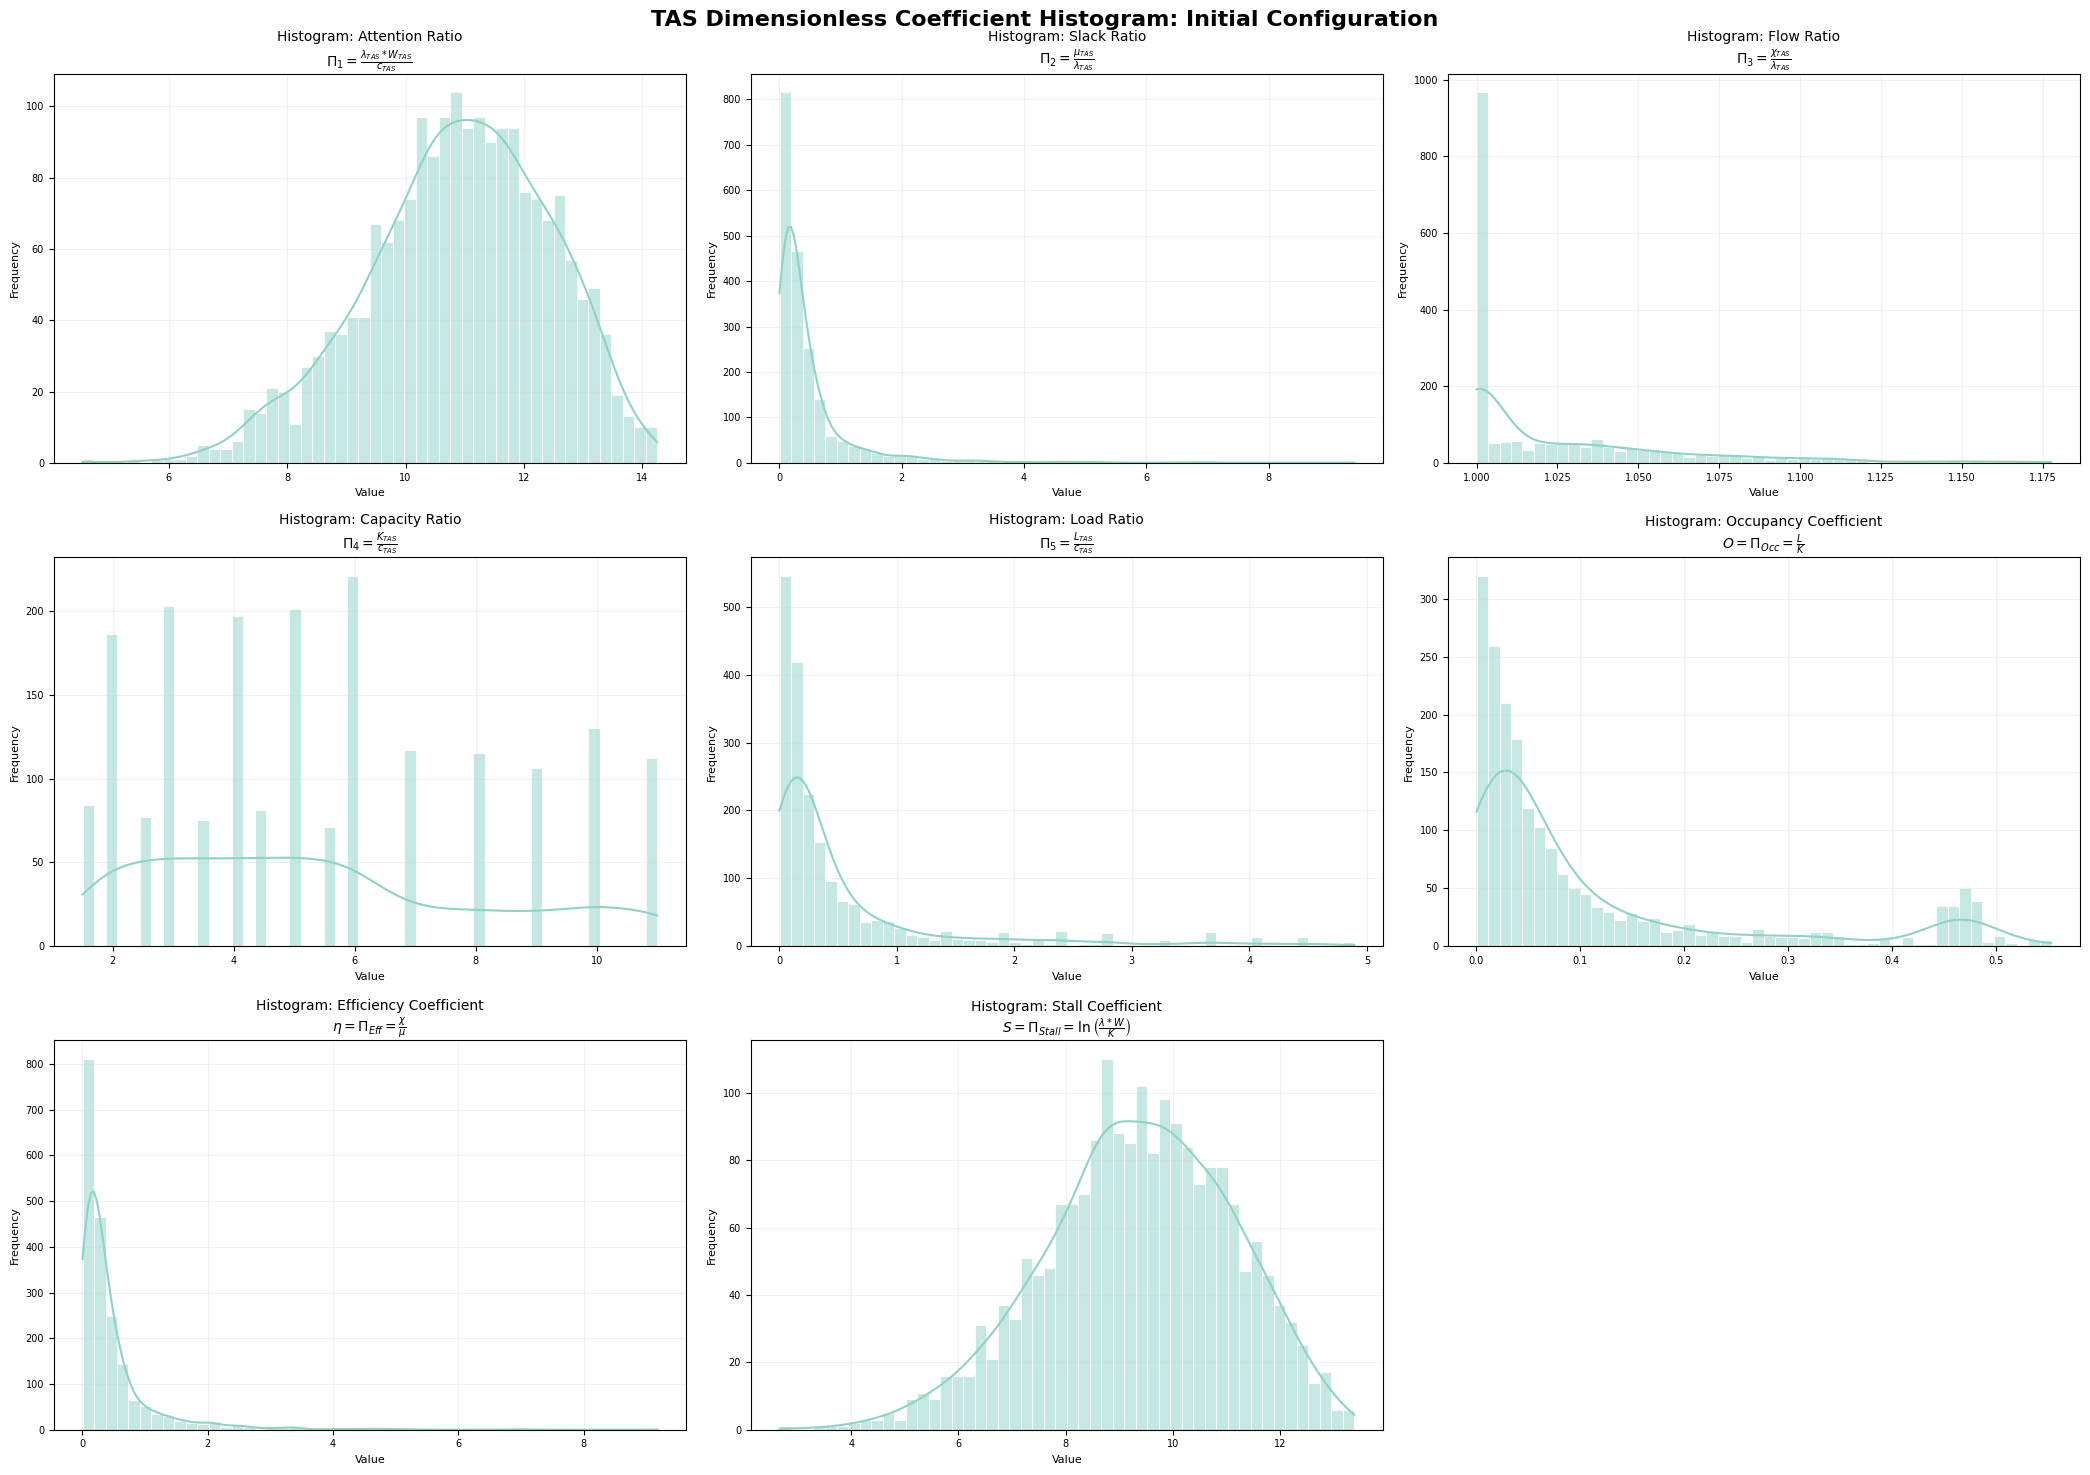

In [61]:
print("--- Plotting Histograms for Coefficients ---")
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# Get all columns to plot
histogram_cols = dflt_sys_coef.columns.tolist()[0:8]
metrics = histogram_cols
max_cols = 3

# copy data for histogram plots
dflt_sys_hist = pd.DataFrame(dflt_sys_coef[histogram_cols])

# labels for the plots
labels = [
    "Attention Ratio",
    "Slack Ratio",
    "Flow Ratio",
    "Capacity Ratio",
    "Load Ratio",
    "Occupancy Coefficient",
    "Efficiency Coefficient",
    "Stall Coefficient",
]

# adjusting Pi_1 to log-scale
dflt_sys_hist[histogram_cols[0]] = np.log1p(dflt_sys_hist[histogram_cols[0]])

# plot dimensionless system chart
title = "TAS Dimensionless Coefficient Histogram: Initial Configuration"
plot_coef_histograms(dflt_sys_hist,
                     max_cols,
                     metrics,
                     labels,
                     title,
                     file_path,
                     "dflt_dimensional_perf_histogram.png",
                     verbose=True,)

--- Charting 3D Dimensionless Coefficients ---
['O=\\Pi_{Occ}=\\frac{L}{K}', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}', 'S=\\Pi_{Stall}=\\ln\\left(\\frac{\\lambda*W}{K}\\right)']
['Occupancy Coefficient', 'Efficiency Coefficient', 'Stall Coefficient']
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_dimensional_exp_chart.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_dimensional_exp_chart.png


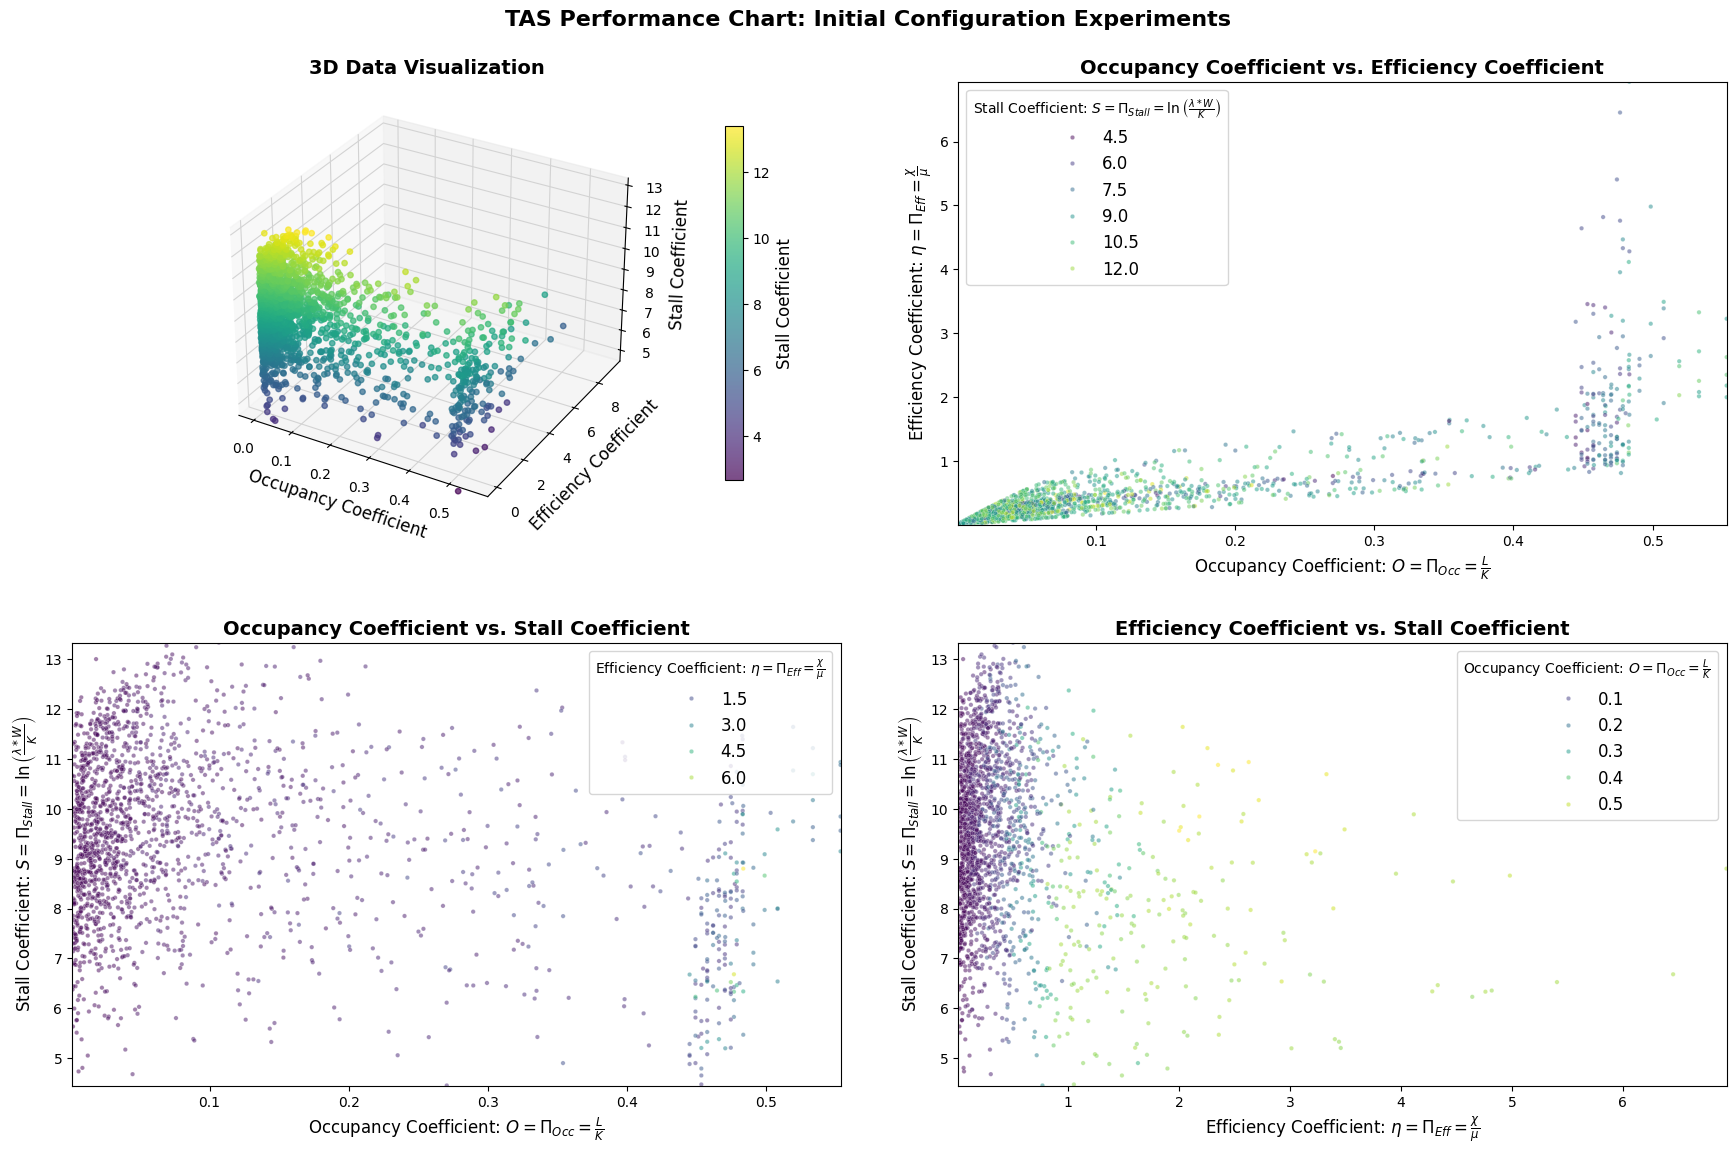

In [62]:
print("--- Charting 3D Dimensionless Coefficients ---")
metrics = dflt_sys_coef[deriv_cols].columns.tolist()

# labels for the plots
labels = [
    "Occupancy Coefficient",
    "Efficiency Coefficient",
    "Stall Coefficient",
]
print(metrics)
print(labels)

# plot dimensionless experiments
title = "TAS Performance Chart: Initial Configuration Experiments"
plot_experiment_coef_chart(dflt_sys_coef[deriv_cols],
                           metrics,
                           labels,
                           title,
                           file_path,
                           "dflt_dimensional_exp_chart.png",
                           percentile={"x": [0.005, 0.999],
                                       "y": [0.005, 0.999],
                                       "z": [0.005, 0.999], },
                           scale={"x": "linear",
                                  "y": "linear",
                                  "z": "linear",},
                           limits={"x": [1e-5, 2.0],
                                   "y": [1e-5, 2.0],
                                   "z": [1.0e-2, 1.0e2],},)

In [63]:
print("--- Creating Alternative Plot 2D DataFrame ---")
# create alternative plot dataframe
# reorganizing columns
plot_cols = [col for col in deriv_cols]
contour = plot_cols.pop()
plot_cols.insert(1, contour)
plot_df = pd.DataFrame(dflt_sys_coef[plot_cols])
plot_df.info()
plot_df.describe()

--- Creating Alternative Plot 2D DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 3 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   O=\Pi_{Occ}=\frac{L}{K}                            1976 non-null   float64
 1   S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)  1976 non-null   float64
 2   \eta=\Pi_{Eff}=\frac{\chi}{\mu}                    1976 non-null   float64
dtypes: float64(3)
memory usage: 46.4 KB


,O=\Pi_{Occ}=\frac{L}{K},S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right),\eta=\Pi_{Eff}=\frac{\chi}{\mu}
count,1976.000000,1976.000000,1976.000000
mean,0.110034,9.352313,0.466032
std,0.142583,1.756593,0.707063
min,0.000388,2.660261,0.003580
25%,0.018896,8.219875,0.108567
50%,0.046418,9.418498,0.245353
75%,0.126934,10.643280,0.509721
max,0.553202,13.386175,9.174610


In [64]:
# sorting by Occ, them by Stall, then by Eff
print(f"Sorting plot data by: {plot_cols}")
plot_df.sort_values(by=plot_cols, inplace=True)
plot_df.reset_index(drop=True, inplace=True)

Sorting plot data by: ['O=\\Pi_{Occ}=\\frac{L}{K}', 'S=\\Pi_{Stall}=\\ln\\left(\\frac{\\lambda*W}{K}\\right)', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}']


In [65]:
print("--- Charting Occupation and Congestion Coefficients ---")
# defining contour range with the efficiency coeffcient range
# aprox to 2nd decimal point
shift_point = 0.10

# min value for contour levels
min_val = plot_df[eff_coef].min() + shift_point

# max value for contour levels
max_val = plot_df[eff_coef].max()

# creating contour levels
n_contours = 10
contour_vals = np.linspace(min_val, max_val, n_contours)
contour_vals = np.round(contour_vals, 2).tolist()
contour_vals[-1] = 0.99

# printing contour levels
print(f"Contour levels from {min_val} to {max_val}: {contour_vals}")

# using contour lines at the beginning of the program
metrics = plot_df.columns.tolist()
labels = [
    "Occupation",       # "Effectiveness",
    "Stall",            # "Stall",
    "Efficiency",       # "Occupation",
]
contour_name = deriv_cols[1]
print(f"Contour levels from: {contour_name}")
print(f"No. of contour lines {len(contour_vals)}")

--- Charting Occupation and Congestion Coefficients ---
Contour levels from 0.10358010115924517 to 9.174609569657983: [0.1, 1.11, 2.12, 3.13, 4.14, 5.14, 6.15, 7.16, 8.17, 0.99]
Contour levels from: \eta=\Pi_{Eff}=\frac{\chi}{\mu}
No. of contour lines 10


In [66]:
# plot this data in regular chart
plot_df.info()
plot_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 3 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   O=\Pi_{Occ}=\frac{L}{K}                            1976 non-null   float64
 1   S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)  1976 non-null   float64
 2   \eta=\Pi_{Eff}=\frac{\chi}{\mu}                    1976 non-null   float64
dtypes: float64(3)
memory usage: 46.4 KB


,O=\Pi_{Occ}=\frac{L}{K},S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right),\eta=\Pi_{Eff}=\frac{\chi}{\mu}
count,1976.000000,1976.000000,1976.000000
mean,0.110034,9.352313,0.466032
std,0.142583,1.756593,0.707063
min,0.000388,2.660261,0.003580
25%,0.018896,8.219875,0.108567
50%,0.046418,9.418498,0.245353
75%,0.126934,10.643280,0.509721
max,0.553202,13.386175,9.174610


--- Plotting TAS Performance Chart ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_dimensional_perf_chart.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\dflt_dimensional_perf_chart.png


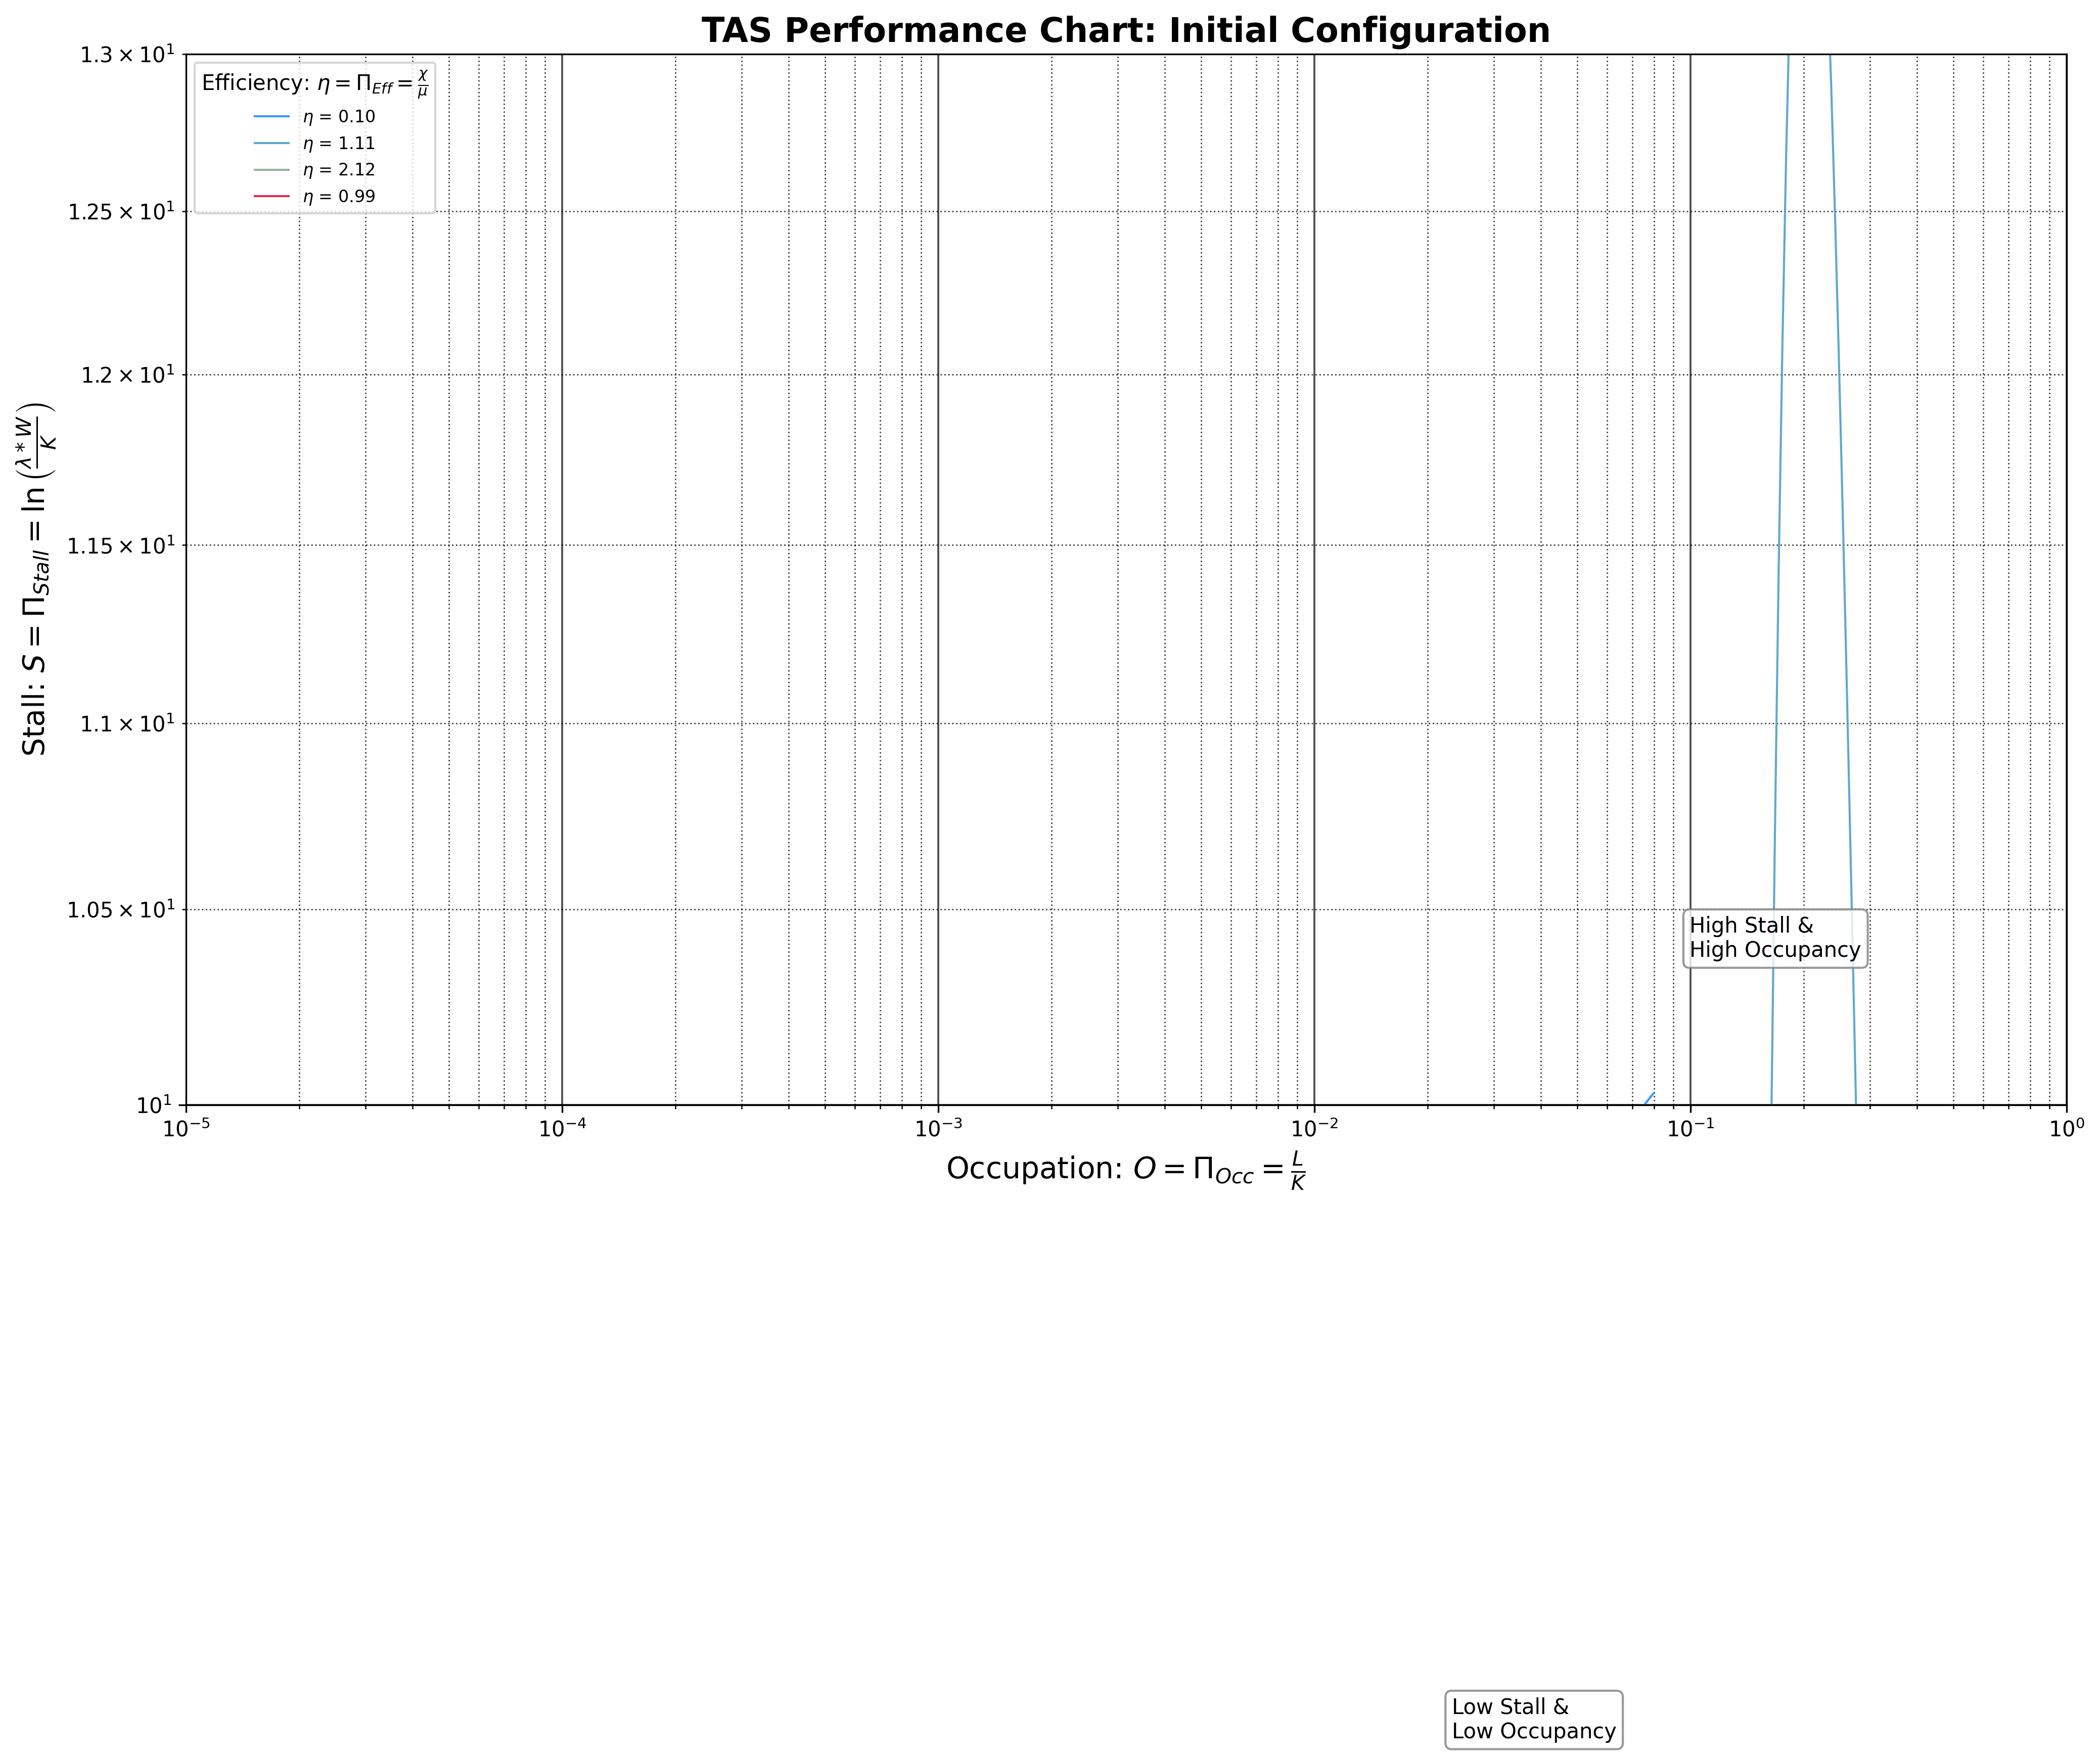

In [67]:
# plotting the queue network dimensionless chart
# selecting images folder
print("--- Plotting TAS Performance Chart ---")
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# plot dimensionless system chart
title = "TAS Performance Chart: Initial Configuration"
plot_performance_coef_chart(plot_df,
                            contour_name,
                            contour_vals,
                            metrics,
                            labels,
                            title,
                            file_path,
                            "dflt_dimensional_perf_chart.png",
                            percentile={"x": [0.005, 0.999],
                                        "y": [0.005, 0.999]},
                            scale={"x": "log", "y": "log"},
                            limits={"x": [1e-5, 1.0],
                                    "y": [1e1, 1.3e1]},)

In [68]:
# cleaning memory
gc.collect()

86327

##### **Optimized Configuration**

In [69]:
# setting case study data folder
file_path = os.path.join(PATH, data_folder, config_folder, cs_folder)
print(f"Data path: {file_path}")

Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1


In [70]:
# Load configuration with mixed queue models
opti_qn_cfg = load(file_path, "optimal_qn_model.csv")
print("Queue Network Configuration:")
opti_qn_cfg.head()


Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1\optimal_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.20,0.40,0.40,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.40,0.20,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [71]:
# Load configuration with mixed queue models
opti_da_cfg = load(file_path, "optimal_dim_variables.csv")
print("Dimension Variables Configuration:")
opti_da_cfg.head()
opti_da_cfg.info()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\config\cs1\optimal_dim_variables.csv
Dimension Variables Configuration:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   _idx          143 non-null    int64  
 1   dm            143 non-null    int64  
 2   _sym          143 non-null    object 
 3   _alias        143 non-null    object 
 4   _fwk          143 non-null    object 
 5   name          143 non-null    object 
 6   description   143 non-null    object 
 7   relevant      143 non-null    bool   
 8   _cat          143 non-null    object 
 9   _dims         143 non-null    object 
 10  _units        143 non-null    object 
 11  _min          143 non-null    float64
 12  _max          143 non-null    float64
 13  _mean         143 non-null    float64
 14  _std_units    143 non-n

In [72]:
print("---- Config Sensitivity & Monte Carlo Samples ----")
n_sens = 100
n_exp = 155
print(f"\tSensitivity Analysis Samples: {n_sens}")
print(f"\tMonte Carlo Simulation Samples: {n_exp}")

---- Config Sensitivity & Monte Carlo Samples ----
	Sensitivity Analysis Samples: 100
	Monte Carlo Simulation Samples: 155


###### **Loading Dimensional Variables**

In [73]:
print("--- Dimensional Var Groups by Dimensional Matrix ---")

# create a dimensional set of variables from config file
opti_dim_var_groups = create_dimensional_groups(opti_da_cfg,
                                                verbose=False)

print(f"--- No. of Dimensional Var Groups: {len(opti_dim_var_groups)} ---")

--- Dimensional Var Groups by Dimensional Matrix ---
--- No. of Dimensional Var Groups: 13 ---


In [74]:
print("--- Configure Simulation Distribution Function for Variables ---")
# configuring distribution functions for dimensional variables

opti_dim_var_groups = configure_dimensional_dist(opti_dim_var_groups,
                                                 verbose=False)

print(f"--- No. of Dimensional Var Groups: {len(opti_dim_var_groups)} ---")

--- Configure Simulation Distribution Function for Variables ---
--- No. of Dimensional Var Groups: 13 ---


###### **Creating Dimensional Model**

In [75]:
print("--- Creating Dimensional Model (Matrix) ---")
print(f"framework: {tas_fwk}, scheme: {tas_scm.sym}\n")
opti_dim_model_groups = create_dimensional_matrix(opti_da_cfg,
                                                  opti_dim_var_groups,
                                                  tas_fwk,
                                                  tas_scm,
                                                  verbose=True)

n = len(opti_dim_model_groups)
print(f"\n--- No. of Dimensional Model Groups: {n} ---")

--- Creating Dimensional Model (Matrix) ---
framework: CUSTOM, scheme: FDU_{Custom TAS}

Dimensional Matrix: 1, with 11 variables.
	Dimensional Matrix 1 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 2, with 11 variables.
	Dimensional Matrix 2 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 3, with 11 variables.
	Dimensional Matrix 3 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 4, with 11 variables.
	Dimensional Matrix 4 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 5, with 11 variables.
	Dimensional Matrix 5 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 6, with 11 variables.
	Dimensional Matrix 6 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 7, with 11 variables.
	Dimensional Matrix 7 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 8, with 11 variables.
	Dimensional Matrix 8 with 11 variables, and 7 relevant variables.
Dimensional Matrix: 9, with 11 variable

In [76]:
print("--- Solving Dimensional Model (Matrix) ----")

opti_dim_model_groups = solve_dimensional_model(opti_dim_model_groups,
                                               verbose=True,
                                               details=True)

n = len(opti_dim_model_groups)
print(f"\n--- No. of Dimensional Model Groups: {n} ---")

--- Solving Dimensional Model (Matrix) ----
	Dimensional Matrix/Model ID: 1, with No. Coefficients: 5
	Creating Matrix for Dimensional Model...
	Solving Matrix for Dimensional Model...
	Finished Solving Dimensional Model: 1
	Model 1, Coefficients Details:
		'\Pi_{0}': \frac{\lambda_{1}*W_{1}}{c_{1}}, [{'\\lambda_{1}': 1, 'c_{1}': -1, 'W_{1}': 1}]
		'\Pi_{1}': \frac{\mu_{1}}{\lambda_{1}}, [{'\\lambda_{1}': -1, '\\mu_{1}': 1}]
		'\Pi_{2}': \frac{\chi_{1}}{\lambda_{1}}, [{'\\lambda_{1}': -1, '\\chi_{1}': 1}]
		'\Pi_{3}': \frac{K_{1}}{c_{1}}, [{'c_{1}': -1, 'K_{1}': 1}]
		'\Pi_{4}': \frac{L_{1}}{c_{1}}, [{'c_{1}': -1, 'L_{1}': 1}]

	Dimensional Matrix/Model ID: 2, with No. Coefficients: 5
	Creating Matrix for Dimensional Model...
	Solving Matrix for Dimensional Model...
	Finished Solving Dimensional Model: 2
	Model 2, Coefficients Details:
		'\Pi_{0}': \frac{\lambda_{2}*W_{2}}{c_{2}}, [{'\\lambda_{2}': 1, 'c_{2}': -1, 'W_{2}': 1}]
		'\Pi_{1}': \frac{\mu_{2}}{\lambda_{2}}, [{'\\lambda_{2}':

###### **Calculating Pi-Coefficients**

In [77]:
print("--- Creating the Sensitivity Groups ---")
print("--- Indexing Sensitivity Groups ---")

# Sensitivity Groups
opti_sens_groups = {}

# create sensitivity analysis for each dimensional model group
opti_sens_groups = create_sensitivity_analysis(opti_dim_model_groups)

print(f"--- No. of Sensitivity Groups: {len(opti_sens_groups)} ---")

--- Creating the Sensitivity Groups ---
--- Indexing Sensitivity Groups ---
--- No. of Sensitivity Groups: 13 ---


###### **Running Sensitivity Analysis**

In [78]:
print("--- Executing Sensitivity Analysis ---")

# executing sensitivity analysis for each sensitivity group
opti_sens_groups = execute_sensitivity_analysis(opti_sens_groups,
                                                vtype="mean",
                                                n_samples=n_sens,
                                                verbose=True,
                                                details=False,)

print(f"--- No. of Sensitivity Groups: {len(opti_sens_groups)} ---")

--- Executing Sensitivity Analysis ---
	Executing Sensitivity Analysis for Group: 1.with 11 variables.
	Finished Sensitivity Analysis for Group: 1.
	Executing Sensitivity Analysis for Group: 2.with 11 variables.
	Finished Sensitivity Analysis for Group: 2.
	Executing Sensitivity Analysis for Group: 3.with 11 variables.
	Finished Sensitivity Analysis for Group: 3.
	Executing Sensitivity Analysis for Group: 4.with 11 variables.
	Finished Sensitivity Analysis for Group: 4.
	Executing Sensitivity Analysis for Group: 5.with 11 variables.
	Finished Sensitivity Analysis for Group: 5.
	Executing Sensitivity Analysis for Group: 6.with 11 variables.
	Finished Sensitivity Analysis for Group: 6.
	Executing Sensitivity Analysis for Group: 7.with 11 variables.
	Finished Sensitivity Analysis for Group: 7.
	Executing Sensitivity Analysis for Group: 8.with 11 variables.
	Finished Sensitivity Analysis for Group: 8.
	Executing Sensitivity Analysis for Group: 9.with 11 variables.
	Finished Sensitivity Ana

In [79]:
print("---- Sensitivity Analysis Post-Processing ----")
# detailed report
# coefficient global index
i = 0

# sensitivity report statistical data
sens_records = []

# global coefficient name = coefficient formula
pi_coef = {}

for dm in opti_sens_groups:
    print(f"Sensitivity Report for Dimensional Model ID: {dm}")
    n = len(opti_sens_groups[dm].results)
    print(f"\tSensitivity Reports Size: {n}")
    for key, val in opti_sens_groups[dm].results.items():
        print(f"\t{key}: {val}")
    print(f"\tEnding Sensitivity report No. {dm}\n")
    # TODO complete this part later, correctly indexing all coefficients

# creating DataFrame from records
opti_node_sens = pd.DataFrame(sens_records)


---- Sensitivity Analysis Post-Processing ----
Sensitivity Report for Dimensional Model ID: 1
	Sensitivity Reports Size: 5
	SEN_{\Pi_{0}}: {'S1': [np.float64(0.08384651189668367), np.float64(0.2697327179896476), np.float64(0.18793662007420442)], 'ST': [np.float64(0.20409526624270447), np.float64(0.9048525847130415), np.float64(0.5861390772066762)], 'S1_conf': [np.float64(0.13484806925010642), np.float64(0.08701456333127645), np.float64(0.11665966478082927)], 'ST_conf': [np.float64(0.12081896939165522), np.float64(0.05701405417165177), np.float64(0.10308669394103522)], 'names': ['W_{1}', 'c_{1}', '\\lambda_{1}']}
	SEN_{\Pi_{1}}: {'S1': [np.float64(0.5844019803993724), np.float64(0.19678805322884393)], 'ST': [np.float64(0.7950626093295914), np.float64(0.33939334711035807)], 'S1_conf': [np.float64(0.12599397594957118), np.float64(0.14239177058100363)], 'ST_conf': [np.float64(0.10529620399585836), np.float64(0.11710179658364496)], 'names': ['\\lambda_{1}', '\\mu_{1}']}
	SEN_{\Pi_{2}}: {'S1

###### **Running Monte Carlo Simulation**

In [80]:
print("--- Create Monte Carlo Simulations ---")
opti_mc_groups = {}

opti_mc_groups = create_monte_carlo_simulation(opti_dim_model_groups,
                                               n_experiments=n_exp,
                                               verbose=True)

print(f"--- No. of Monte Carlo Simulation Groups: {len(opti_mc_groups)} ---")

--- Create Monte Carlo Simulations ---
	Created Monte Carlo Simulation for Group: 1.with 11 variables.
	Created Monte Carlo Simulation for Group: 2.with 11 variables.
	Created Monte Carlo Simulation for Group: 3.with 11 variables.
	Created Monte Carlo Simulation for Group: 4.with 11 variables.
	Created Monte Carlo Simulation for Group: 5.with 11 variables.
	Created Monte Carlo Simulation for Group: 6.with 11 variables.
	Created Monte Carlo Simulation for Group: 7.with 11 variables.
	Created Monte Carlo Simulation for Group: 8.with 11 variables.
	Created Monte Carlo Simulation for Group: 9.with 11 variables.
	Created Monte Carlo Simulation for Group: 10.with 11 variables.
	Created Monte Carlo Simulation for Group: 11.with 11 variables.
	Created Monte Carlo Simulation for Group: 12.with 11 variables.
	Created Monte Carlo Simulation for Group: 13.with 11 variables.
--- No. of Monte Carlo Simulation Groups: 13 ---


In [81]:
print("--- Executing Monte Carlo Simulations ---")

opti_mc_groups = execute_monte_carlo(opti_mc_groups,
                                     n_samples=n_exp,
                                     verbose=True)

print(f"--- No. of Monte Carlo Simulation Groups: {len(opti_mc_groups)} ---")

--- Executing Monte Carlo Simulations ---
	Executing Monte Carlo Simulation for Group: 1 with 11 variables.
	Finished Monte Carlo Simulation for Group: 1.
	Executing Monte Carlo Simulation for Group: 2 with 11 variables.
	Finished Monte Carlo Simulation for Group: 2.
	Executing Monte Carlo Simulation for Group: 3 with 11 variables.
	Finished Monte Carlo Simulation for Group: 3.
	Executing Monte Carlo Simulation for Group: 4 with 11 variables.
	Finished Monte Carlo Simulation for Group: 4.
	Executing Monte Carlo Simulation for Group: 5 with 11 variables.
	Finished Monte Carlo Simulation for Group: 5.
	Executing Monte Carlo Simulation for Group: 6 with 11 variables.
	Finished Monte Carlo Simulation for Group: 6.
	Executing Monte Carlo Simulation for Group: 7 with 11 variables.
	Finished Monte Carlo Simulation for Group: 7.
	Executing Monte Carlo Simulation for Group: 8 with 11 variables.
	Finished Monte Carlo Simulation for Group: 8.
	Executing Monte Carlo Simulation for Group: 9 with 11

###### **Plotting Dimensional Model Chart**

In [82]:
print("--- Monte Carlo Simulation Post-Processing (Exp + Stats) ----")

# Call the function to process results
answer = process_monte_carlo_results(opti_mc_groups,
                                     verbose=True)
opti_mc_exp, opti_mc_stats, pi_coef = answer

print(f"--- No. of Monte Carlo Simulation Records: {len(opti_mc_exp)} ---")
print(f"--- No. of Monte Carlo Simulation Statistics: {len(opti_mc_stats)} ---")
print(f"--- No. of Monte Carlo Simulation Coefficients: {len(pi_coef)} ---")


--- Monte Carlo Simulation Post-Processing (Exp + Stats) ----
	Post-Processing Monte Carlo Results for Group: 1, with 11 variables, and 155 iterations.
		Processing Coefficient: Pi-0: \Pi_{0} = \frac{\lambda_{1}*W_{1}}{c_{1}}
		Global Idx: 0, Local Idx: 0, Inputs := ['\\lambda_{1}', 'c_{1}', 'W_{1}'], Size: 3
		Renaming Coef. FROM: \Pi_{0} TO: \Pi_{0}
		Processing Coefficient: Pi-1: \Pi_{1} = \frac{\mu_{1}}{\lambda_{1}}
		Global Idx: 1, Local Idx: 1, Inputs := ['\\lambda_{1}', '\\mu_{1}'], Size: 2
		Renaming Coef. FROM: \Pi_{1} TO: \Pi_{1}
		Processing Coefficient: Pi-2: \Pi_{2} = \frac{\chi_{1}}{\lambda_{1}}
		Global Idx: 2, Local Idx: 2, Inputs := ['\\lambda_{1}', '\\chi_{1}'], Size: 2
		Renaming Coef. FROM: \Pi_{2} TO: \Pi_{2}
		Processing Coefficient: Pi-3: \Pi_{3} = \frac{K_{1}}{c_{1}}
		Global Idx: 3, Local Idx: 3, Inputs := ['c_{1}', 'K_{1}'], Size: 2
		Renaming Coef. FROM: \Pi_{3} TO: \Pi_{3}
		Processing Coefficient: Pi-4: \Pi_{4} = \frac{L_{1}}{c_{1}}
		Global Idx: 4, Local I

In [83]:
print("--- Saving Monte Carlo Simulation Experiment Results ---")
# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_node_exp.csv", opti_mc_exp)

print(opti_mc_exp.shape)
opti_mc_exp.info()
opti_mc_exp.head()

--- Saving Monte Carlo Simulation Experiment Results ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_dimensional_node_exp.csv
(155, 208)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Columns: 208 entries, \lambda_{1}@\Pi_{0} to \Pi_{64}
dtypes: float64(208)
memory usage: 252.0 KB


,\lambda_{1}@\Pi_{0},W_{1}@\Pi_{0},c_{1}@\Pi_{0},\Pi_{0},\mu_{1}@\Pi_{1},\lambda_{1}@\Pi_{1},\Pi_{1},\chi_{1}@\Pi_{2},\lambda_{1}@\Pi_{2},\Pi_{2},...,\Pi_{61},\chi_{13}@\Pi_{62},\lambda_{13}@\Pi_{62},\Pi_{62},K_{13}@\Pi_{63},c_{13}@\Pi_{63},\Pi_{63},L_{13}@\Pi_{64},c_{13}@\Pi_{64},\Pi_{64}
0,469.308058,0.006285,2.0,149349.855744,253.935349,469.308058,1.848140,469.308058,469.308058,1.0,...,0.208459,156.654139,156.654139,1.0,5.0,2.0,2.5,0.210735,2.0,0.105367
1,259.303243,0.002955,2.0,175528.027991,382.400938,259.303243,0.678093,259.303243,259.303243,1.0,...,0.152289,61.998147,61.998147,1.0,12.0,2.0,6.0,0.153177,2.0,0.076589
2,409.867620,0.002111,2.0,388357.803077,545.175358,409.867620,0.751809,409.867620,409.867620,1.0,...,0.191622,97.072236,97.072236,1.0,8.0,1.0,8.0,0.237042,1.0,0.237042
3,514.664241,0.001639,1.0,313926.274823,1123.890650,514.664241,0.457931,514.664241,514.664241,1.0,...,0.402105,90.837801,90.837801,1.0,7.0,1.0,7.0,0.667063,1.0,0.667063
4,129.322839,0.000855,2.0,302499.959750,1173.117603,129.322839,0.110239,129.322839,129.322839,1.0,...,0.048815,58.717937,58.717937,1.0,10.0,2.0,5.0,0.048844,2.0,0.024422


In [84]:
print("--- Saving Monte Carlo Simulation Statistics ---")
# save data
# select result folder
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_node_stats.csv", opti_mc_stats)

print(opti_mc_stats.shape)
opti_mc_stats.info()
opti_mc_stats.head()

--- Saving Monte Carlo Simulation Statistics ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_dimensional_node_stats.csv
(65, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      65 non-null     object 
 1   coef      65 non-null     object 
 2   mean      65 non-null     float64
 3   median    65 non-null     float64
 4   std_dev   65 non-null     float64
 5   variance  65 non-null     float64
 6   min       65 non-null     float64
 7   max       65 non-null     float64
 8   count     65 non-null     int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 4.7+ KB


,name,coef,mean,median,std_dev,variance,min,max,count
0,\Pi_{0},\frac{\lambda_{1}*W_{1}}{c_{1}},391071.440258,280634.129101,418652.842725,1.752702e+11,7094.350541,1.885614e+06,155
1,\Pi_{1},\frac{\mu_{1}}{\lambda_{1}},0.670627,0.424470,0.780833,6.096996e-01,0.053093,4.940378e+00,155
2,\Pi_{2},\frac{\chi_{1}}{\lambda_{1}},1.000000,1.000000,0.000000,0.000000e+00,1.000000,1.000000e+00,155
3,\Pi_{3},\frac{K_{1}}{c_{1}},5.177419,4.500000,2.636433,6.950780e+00,1.500000,1.100000e+01,155
4,\Pi_{4},\frac{L_{1}}{c_{1}},0.800848,0.338614,1.073507,1.152416e+00,0.026565,4.892607e+00,155


In [85]:

print("--- Renaming Pi-Coefficients from DataFrame ---")
# Extracting just the coefficients from the experimental DataFrame
pi_keys = list(pi_coef.keys())
print(f"Total No. of Pi-Coefficients: {len(pi_keys)}")
opti_pi_coefs = pd.DataFrame(opti_mc_exp[pi_keys])

pi_cols = {}
# renaming columns with coef = formula
for k, v in pi_coef.items():
    pi_cols[k] = f"{k}={v}"

# renaming columns
opti_pi_coefs.rename(columns=pi_cols, inplace=True)
print("--- Finished Renaming Pi-Coefficients from DataFrame ---")

--- Renaming Pi-Coefficients from DataFrame ---
Total No. of Pi-Coefficients: 65
--- Finished Renaming Pi-Coefficients from DataFrame ---


In [86]:
print("--- Saving Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_node_coeffs.csv", opti_pi_coefs)

# checking the Pi DataFrame
print(opti_pi_coefs.shape)
opti_pi_coefs.info()
opti_pi_coefs.head()

--- Saving Pi-Coefficients from Monte Carlo Simulation ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_dimensional_node_coeffs.csv
(155, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 65 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   \Pi_{0}=\frac{\lambda_{1}*W_{1}}{c_{1}}      155 non-null    float64
 1   \Pi_{1}=\frac{\mu_{1}}{\lambda_{1}}          155 non-null    float64
 2   \Pi_{2}=\frac{\chi_{1}}{\lambda_{1}}         155 non-null    float64
 3   \Pi_{3}=\frac{K_{1}}{c_{1}}                  155 non-null    float64
 4   \Pi_{4}=\frac{L_{1}}{c_{1}}                  155 non-null    float64
 5   \Pi_{5}=\frac{\lambda_{2}*W_{2}}{c_{2}}      155 no

,\Pi_{0}=\frac{\lambda_{1}*W_{1}}{c_{1}},\Pi_{1}=\frac{\mu_{1}}{\lambda_{1}},\Pi_{2}=\frac{\chi_{1}}{\lambda_{1}},\Pi_{3}=\frac{K_{1}}{c_{1}},\Pi_{4}=\frac{L_{1}}{c_{1}},\Pi_{5}=\frac{\lambda_{2}*W_{2}}{c_{2}},\Pi_{6}=\frac{\mu_{2}}{\lambda_{2}},\Pi_{7}=\frac{\chi_{2}}{\lambda_{2}},\Pi_{8}=\frac{K_{2}}{c_{2}},\Pi_{9}=\frac{L_{2}}{c_{2}},...,\Pi_{55}=\frac{\lambda_{12}*W_{12}}{c_{12}},\Pi_{56}=\frac{\mu_{12}}{\lambda_{12}},\Pi_{57}=\frac{\chi_{12}}{\lambda_{12}},\Pi_{58}=\frac{K_{12}}{c_{12}},\Pi_{59}=\frac{L_{12}}{c_{12}},\Pi_{60}=\frac{\lambda_{13}*W_{13}}{c_{13}},\Pi_{61}=\frac{\mu_{13}}{\lambda_{13}},\Pi_{62}=\frac{\chi_{13}}{\lambda_{13}},\Pi_{63}=\frac{K_{13}}{c_{13}},\Pi_{64}=\frac{L_{13}}{c_{13}}
0,149349.855744,1.848140,1.0,3.0,1.474726,360933.380509,0.112589,1.0,6.0,0.056473,...,180961.224621,0.496111,1.0,5.5,0.264319,232904.506496,0.208459,1.0,2.5,0.105367
1,175528.027991,0.678093,1.0,5.5,0.383062,108106.708562,0.417407,1.0,7.0,0.709086,...,19276.084931,0.551209,1.0,9.0,1.202248,50187.161340,0.152289,1.0,6.0,0.076589
2,388357.803077,0.751809,1.0,3.0,0.432569,53889.334519,0.446805,1.0,7.0,0.794953,...,214875.708731,0.217609,1.0,10.0,0.278133,39752.540604,0.191622,1.0,8.0,0.237042
3,313926.274823,0.457931,1.0,11.0,0.843763,4074.293113,1.438203,1.0,7.0,3.231475,...,154840.210743,0.160104,1.0,6.0,0.190605,12369.896129,0.402105,1.0,7.0,0.667063
4,302499.959750,0.110239,1.0,5.5,0.055287,311005.540472,0.125970,1.0,2.0,0.063231,...,29183.632622,0.249957,1.0,3.0,0.126959,141175.121255,0.048815,1.0,5.0,0.024422


In [87]:
# make generic columns for dimensionless coefficients
print("--- Creating Generic Columns for Dimensionless Coefficients ---")
sys_name = "TAS"
sys_cols = [re.sub(r"\d+", sys_name, col) for col in pi_coef.values()]

# removing redundant entries, keeping order
sys_cols = list(dict.fromkeys(sys_cols))
for i in range(len(sys_cols)):
    formula = sys_cols[i]
    sys_cols[i] = f"\\Pi_{{{i+1}}}={formula}"

print(f"System generic columns: {len(sys_cols)}, {sys_cols}")

--- Creating Generic Columns for Dimensionless Coefficients ---
System generic columns: 5, ['\\Pi_{1}=\\frac{\\lambda_{TAS}*W_{TAS}}{c_{TAS}}', '\\Pi_{2}=\\frac{\\mu_{TAS}}{\\lambda_{TAS}}', '\\Pi_{3}=\\frac{\\chi_{TAS}}{\\lambda_{TAS}}', '\\Pi_{4}=\\frac{K_{TAS}}{c_{TAS}}', '\\Pi_{5}=\\frac{L_{TAS}}{c_{TAS}}']


In [88]:
print("--- Post-Processing System Pi-Coefficients ---")
print(f"Pi-Coefficients shape: {opti_pi_coefs.shape}")
# dictionary for system records
opti_sys_coef = consolidate_simulation_results(opti_pi_coefs,
                                               sys_cols,
                                               verbose=False,
                                               details=False)

print(f"System Pi-Coefficients shape: {opti_sys_coef.shape}")


--- Post-Processing System Pi-Coefficients ---
Pi-Coefficients shape: (155, 65)
System Pi-Coefficients shape: (2015, 5)


In [89]:
print("--- Checking System Records Info ---")
print("--- System DataFrame ---")
print(opti_sys_coef.shape)
opti_sys_coef.info()
opti_sys_coef.head()

--- Checking System Records Info ---
--- System DataFrame ---
(2015, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 5 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}  2015 non-null   float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}        2015 non-null   float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}       2015 non-null   float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                2015 non-null   float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                2015 non-null   float64
dtypes: float64(5)
memory usage: 78.8 KB


,\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}},\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}},\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}},\Pi_{4}=\frac{K_{TAS}}{c_{TAS}},\Pi_{5}=\frac{L_{TAS}}{c_{TAS}}
0,149349.855744,1.848140,1.0,3.0,1.474726
1,175528.027991,0.678093,1.0,5.5,0.383062
2,388357.803077,0.751809,1.0,3.0,0.432569
3,313926.274823,0.457931,1.0,11.0,0.843763
4,302499.959750,0.110239,1.0,5.5,0.055287


In [90]:
# creating derived Pi-Coefficients
print("---- Creating Derived Pi-Coefficients ----")
# derived coefficients columns
# defining plot colums
deriv_cols = []

# >>> working variables for derived a new coefficient
# Occupation Coefficient: Pi_8 = Pi_5 * Pi_4^{-1} = L / K
name = "Occ"
print(f"Creating System Occupancy Coefficient: \\Pi_{{{name}}}")

# Pi_4 = L / c
temp = f"\\Pi_{{4}}=\\frac{{K_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_4 = opti_sys_coef[temp]

# Pi_5 = L / c
temp = f"\\Pi_{{5}}=\\frac{{L_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_5 = opti_sys_coef[temp]

numerator = "L"
denominator = "K"

# Pi_6 = L * c / (K * c) = L / K
occ_coef = f"O=\\Pi_{{{name}}}=\\frac{{{numerator}}}{{{denominator}}}"
opti_sys_coef[occ_coef] = np.log1p(pi_5 * (pi_4**-1))
# opti_sys_coef[occ_coef] = pi_5 * (pi_4**-1)

# >>> working variables for derived a new coefficient
# Service Effectiveness Coef: Pi_6 = Pi_2 * Pi_3^{-1} = chi / mu
name = "Eff"
print(f"Creating System Congestion Coefficient: \\Pi_{{{name}}}")

# Pi_2 = mu / lambda
temp = f"\\Pi_{{2}}=\\frac{{\\mu_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_2 = opti_sys_coef[temp]

# Pi_3 = chi / lambda
temp = f"\\Pi_{{3}}=\\frac{{\\chi_{{{sys_name}}}}}{{\\lambda_{{{sys_name}}}}}"
pi_3 = opti_sys_coef[temp]

numerator = "\\chi"
denominator = "\\mu"

# Pi_7 = chi * lambda / (mu * lambda) = chi / mu
eff_coef = f"\\eta="
eff_coef += f"\\Pi_{{{name}}}=\\frac{{{numerator}}}{{{denominator}}}"
opti_sys_coef[eff_coef] = np.log1p(pi_2 * (pi_3**-1))
# opti_sys_coef[eff_coef] = pi_2 * (pi_3**-1)

# >>> working variables for derived a new coefficient
# normalizing P_1 by another coefficient to improve readbility
# Stall Coefficient: Pi_7 = P_1 * P_4^(-1) = lambda * W / K
# Adjusted in log-space: Ln(P_7 + 1 )= Ln(lambda * W / K + 1)
name = "Stall"
print(f"Creating System Stall Coefficient: \\Pi_{{{name}}}")

# Pi_1 = lambda * W / c
numerator = f"\\lambda_{{{sys_name}}}*W_{{{sys_name}}}"
denominator = f"c_{{{sys_name}}}"
temp = f"\\Pi_{{1}}=\\frac{{{numerator}}}{{{denominator}}}"
pi_1 = opti_sys_coef[temp]

# Pi_4 = K / c
temp = f"\\Pi_{{4}}=\\frac{{K_{{{sys_name}}}}}{{c_{{{sys_name}}}}}"
pi_4 = opti_sys_coef[temp]

# Pi_8 = Lambda * W / c -> Pi_7 = ln(Pi_7 + 1)
stall_coef = f"S=\\Pi_{{{name}}}="
stall_coef += f"\\ln\\left(\\frac{{\\lambda*W}}{{K}}\\right)"
opti_sys_coef[stall_coef] = np.log(pi_1 * (pi_4**-1) + 1e-6)
# opti_sys_coef[stall_coef] = pi_1 * (pi_4**-1)

# name = "Util"
# print(f"Creating System Utilization Coefficient: \\Pi_{{{name}}}")

# numerator = "\\lambda"
# denominator = "\\mu"

# util_coef = "\\rho="   # f"\\Pi_{{9}}="
# util_coef += f"\\Pi_{{{name}}}=\\ln(\\frac{{{numerator}}}{{{denominator}}})"
# # Pi_9 = lambda / mu
# pi_9 = pi_2**-1
# opti_sys_coef[util_coef] = np.log1p(pi_9)

# change order to change chart distribution
# x-axis, y-axis, z-axis/contourn
deriv_cols.append(occ_coef)
deriv_cols.append(eff_coef)
deriv_cols.append(stall_coef)
# deriv_cols.append(util_coef)

# checking derived coefficients
print(f"Derived Coefficients: {len(deriv_cols)}, {deriv_cols}")

# sort by first colum from lower to highest value
# opti_sys_coef.sort_values(by=deriv_cols[0], inplace=True)
# opti_sys_coef.reset_index(drop=True, inplace=True)

---- Creating Derived Pi-Coefficients ----
Creating System Occupancy Coefficient: \Pi_{Occ}
Creating System Congestion Coefficient: \Pi_{Eff}
Creating System Stall Coefficient: \Pi_{Stall}
Derived Coefficients: 3, ['O=\\Pi_{Occ}=\\frac{L}{K}', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}', 'S=\\Pi_{Stall}=\\ln\\left(\\frac{\\lambda*W}{K}\\right)']


In [91]:
# giving coefficients a name for  readbility
print("--- Naming System Pi-Coefficients ---")
names = [
    f"\\Pi_{{Occ}}",    # Occupancy Coefficient
    f"\\Pi_{{Eff}}",    # Efficiency Coefficient
    f"\\Pi_{{Stall}}",  # Stall Coefficient
    # f"\\Pi_{{Util}}",   # Utilization Coefficient
]

# adding the new columns for simplicity
for src, tgt in zip(deriv_cols, names):
    opti_sys_coef[tgt] = opti_sys_coef[src]

opti_sys_coef.info()

--- Naming System Pi-Coefficients ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      2015 non-null   float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            2015 non-null   float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           2015 non-null   float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    2015 non-null   float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    2015 non-null   float64
 5   O=\Pi_{Occ}=\frac{L}{K}                            2015 non-null   float64
 6   \eta=\Pi_{Eff}=\frac{\chi}{\mu}                    2015 non-null   float64
 7   S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)  2015 non-null   float64
 8   \Pi_{Occ}                                         

In [92]:
print("\n--- System Pi-Coefficients from Monte Carlo Simulation ---")

# save data
# select result folder
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_dimensional_net_coeffs.csv", opti_sys_coef)
opti_sys_coef.info()
opti_sys_coef.describe()


--- System Pi-Coefficients from Monte Carlo Simulation ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\data\opti_dimensional_net_coeffs.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2015 entries, 0 to 2014
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      2015 non-null   float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            2015 non-null   float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           2015 non-null   float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    2015 non-null   float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    2015 non-null   float64
 5   O=\Pi_{Occ}=\frac

,\Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}},\Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}},\Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}},\Pi_{4}=\frac{K_{TAS}}{c_{TAS}},\Pi_{5}=\frac{L_{TAS}}{c_{TAS}},O=\Pi_{Occ}=\frac{L}{K},\eta=\Pi_{Eff}=\frac{\chi}{\mu},S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right),\Pi_{Occ},\Pi_{Eff},\Pi_{Stall}
count,2.015000e+03,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000
mean,1.283371e+05,0.456879,1.019949,5.518859,0.554398,0.095946,0.314194,9.179281,0.095946,0.314194,9.179281
std,2.057690e+05,0.652573,0.028693,2.799381,0.882400,0.115018,0.303293,1.770668,0.115018,0.303293,1.770668
min,1.259520e+02,0.000726,1.000000,1.500000,0.000726,0.000121,0.000725,2.438006,0.000121,0.000725,2.438006
25%,1.606919e+04,0.125574,1.000000,3.000000,0.098467,0.019800,0.115029,8.008572,0.019800,0.115029,8.008572
50%,5.068002e+04,0.247616,1.003409,5.000000,0.212376,0.045828,0.215889,9.207191,0.045828,0.215889,9.207191
75%,1.438659e+05,0.489834,1.034029,8.000000,0.568305,0.119693,0.392565,10.428526,0.119693,0.392565,10.428526
max,1.885614e+06,6.430234,1.118774,11.000000,4.892607,0.440318,1.998188,14.044299,0.440318,1.998188,14.044299


In [93]:
print("--- Cleaning Invalid Values from Plot Data ---")
# clear plot data
LIM_FLOW = 1.0
LIM_BUFFER = 1.0

# clear x-axis: occ < 1.0
print(f"cleaning invalid values in: {occ_coef}")
opti_sys_coef = opti_sys_coef[opti_sys_coef[occ_coef] < LIM_BUFFER]
print(f"Plot data with {occ_coef} < {LIM_BUFFER}: {opti_sys_coef.shape}")

# y-axis: eta < 1.0
print(f"cleaning invalid values in: {eff_coef}")
opti_sys_coef = opti_sys_coef[opti_sys_coef[eff_coef] < LIM_FLOW]
print(f"Plot data with {eff_coef} < {LIM_FLOW}: {opti_sys_coef.shape}")
opti_sys_coef.info()

--- Cleaning Invalid Values from Plot Data ---
cleaning invalid values in: O=\Pi_{Occ}=\frac{L}{K}
Plot data with O=\Pi_{Occ}=\frac{L}{K} < 1.0: (2015, 11)
cleaning invalid values in: \eta=\Pi_{Eff}=\frac{\chi}{\mu}
Plot data with \eta=\Pi_{Eff}=\frac{\chi}{\mu} < 1.0: (1919, 11)
<class 'pandas.core.frame.DataFrame'>
Index: 1919 entries, 1 to 2014
Data columns (total 11 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}      1919 non-null   float64
 1   \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}            1919 non-null   float64
 2   \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}           1919 non-null   float64
 3   \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}                    1919 non-null   float64
 4   \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}                    1919 non-null   float64
 5   O=\Pi_{Occ}=\frac{L}{K}                            1

--- Plotting Histograms for Coefficients ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img
	Plotting Histogram 1/8: \Pi_{1}=\frac{\lambda_{TAS}*W_{TAS}}{c_{TAS}}
	Plotting Histogram 2/8: \Pi_{2}=\frac{\mu_{TAS}}{\lambda_{TAS}}
	Plotting Histogram 3/8: \Pi_{3}=\frac{\chi_{TAS}}{\lambda_{TAS}}
	Plotting Histogram 4/8: \Pi_{4}=\frac{K_{TAS}}{c_{TAS}}
	Plotting Histogram 5/8: \Pi_{5}=\frac{L_{TAS}}{c_{TAS}}
	Plotting Histogram 6/8: O=\Pi_{Occ}=\frac{L}{K}
	Plotting Histogram 7/8: \eta=\Pi_{Eff}=\frac{\chi}{\mu}
	Plotting Histogram 8/8: S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)


c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\src\view\plots.py:1681: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_dimensional_perf_histogram.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_dimensional_perf_histogram.png


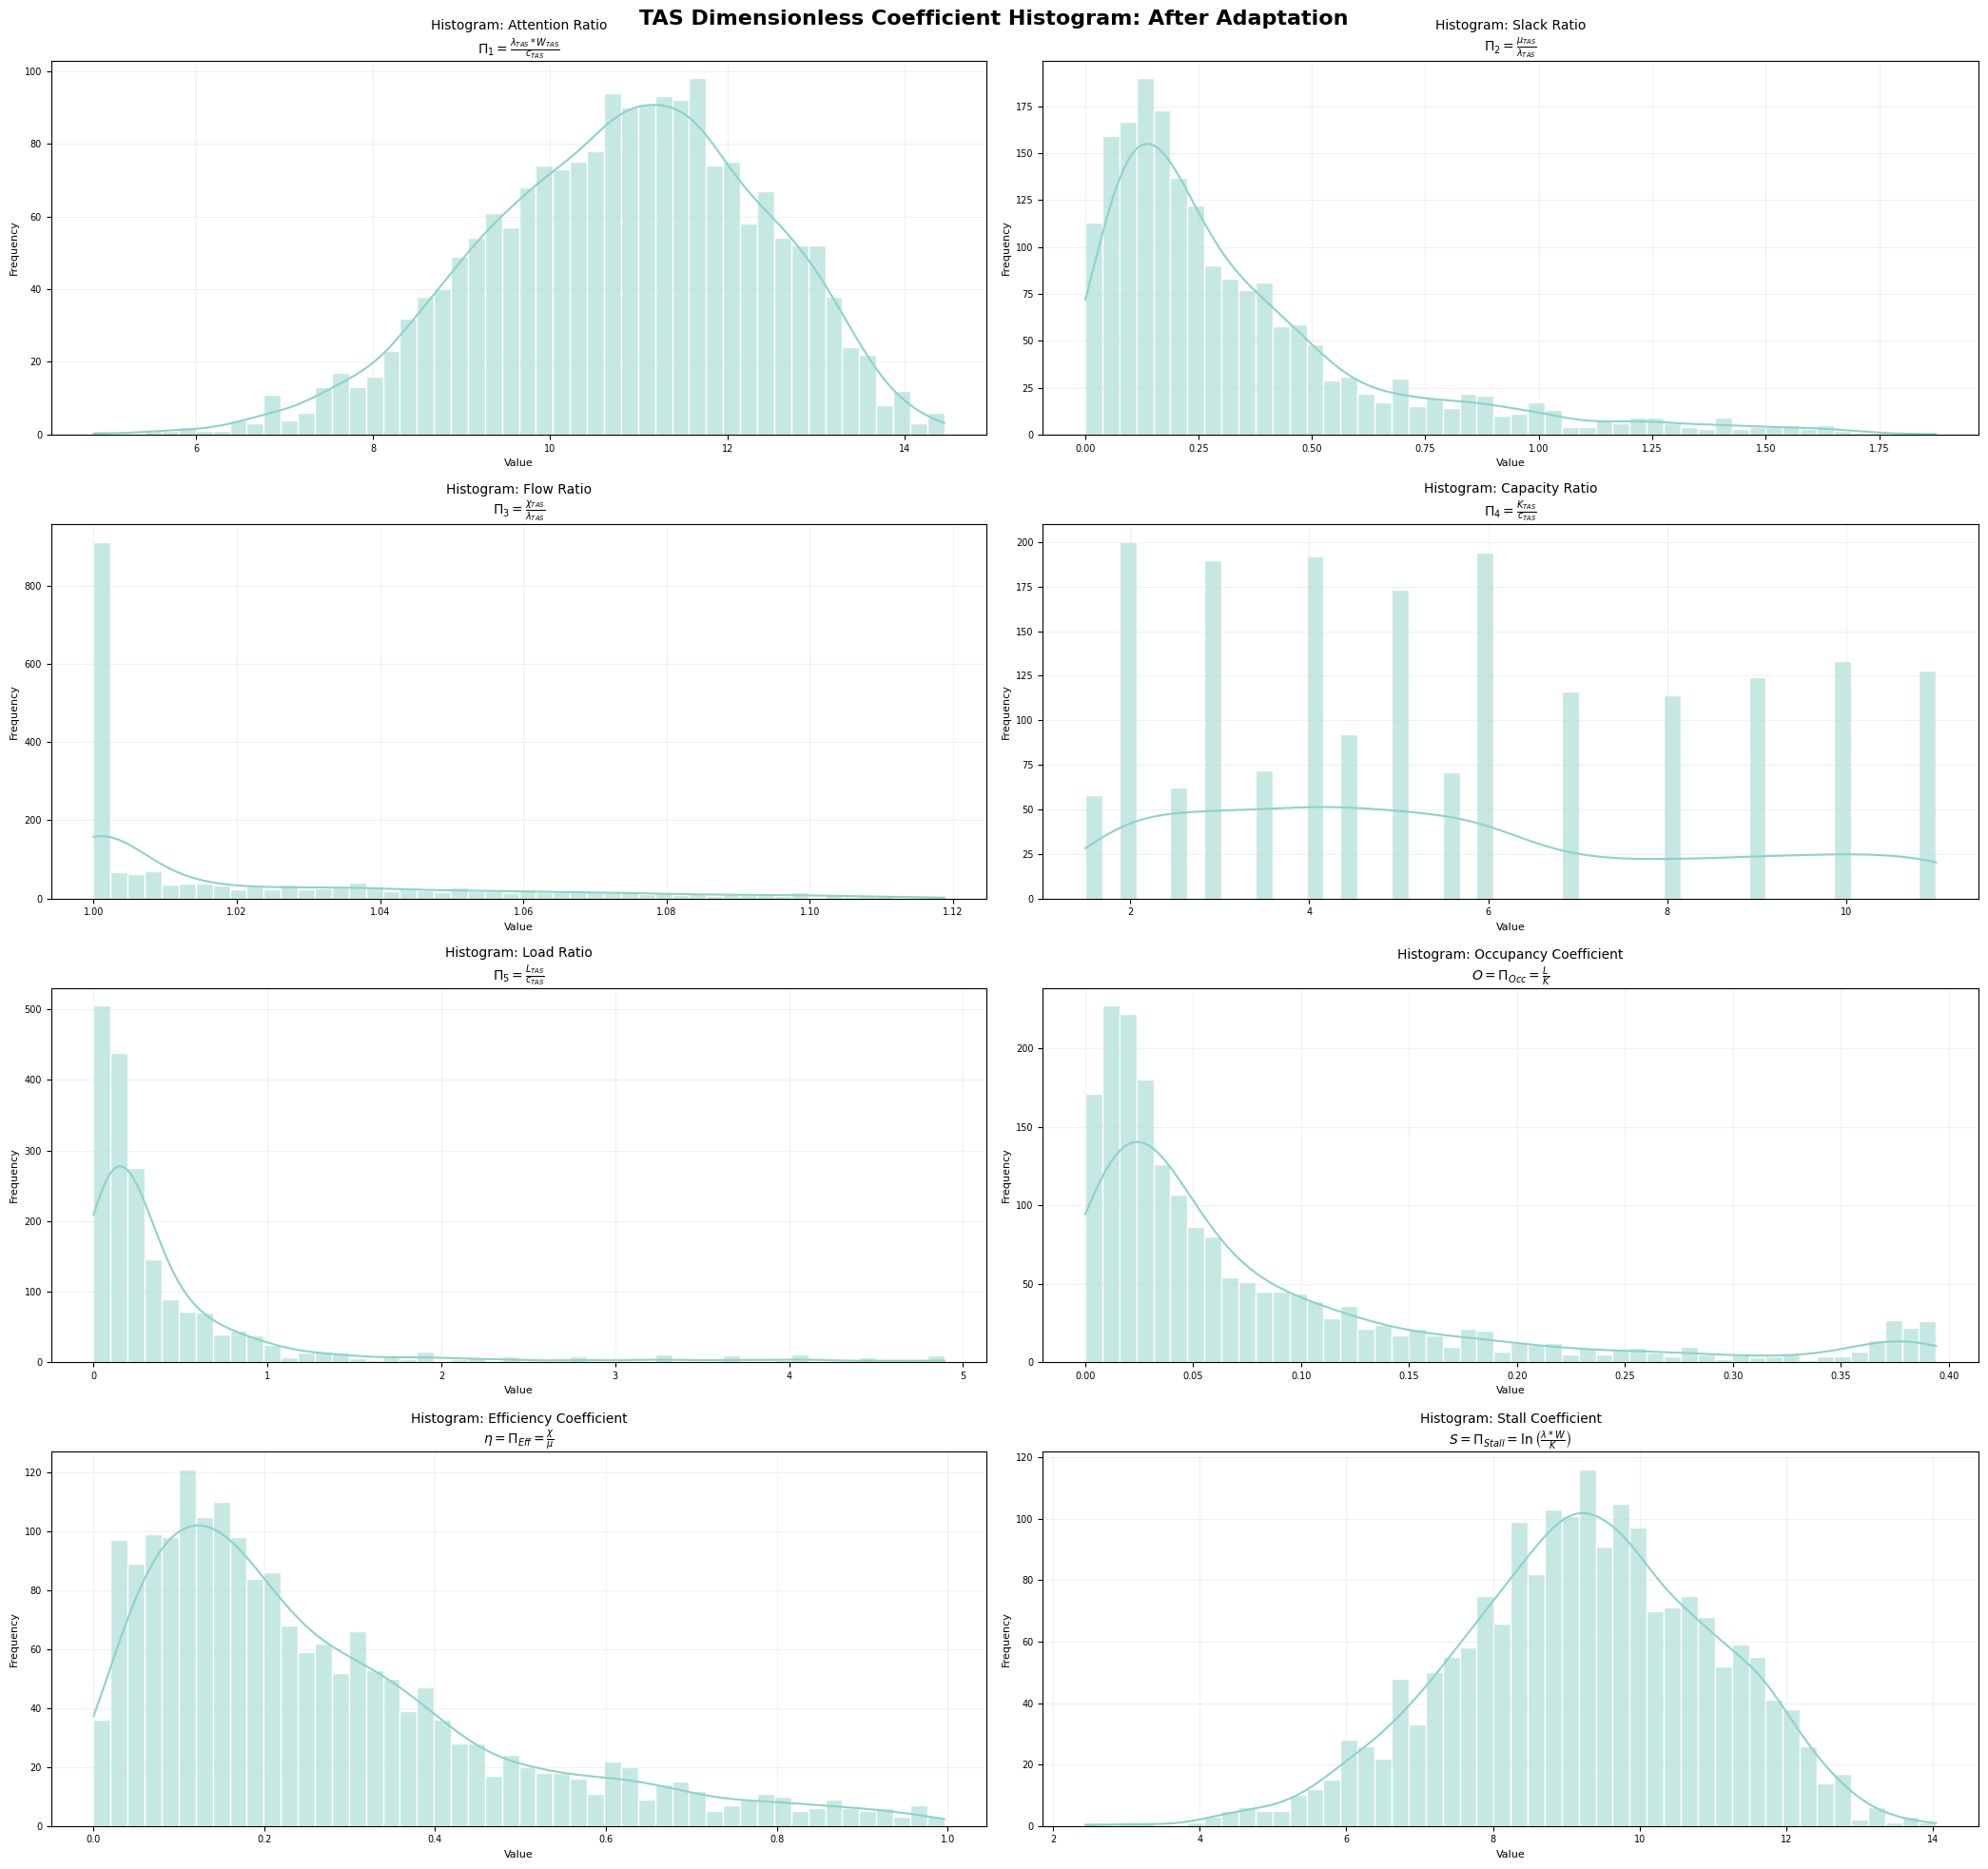

In [94]:
print("--- Plotting Histograms for Coefficients ---")
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# Get all columns to plot
histogram_cols = dflt_sys_coef.columns.tolist()[0:8]
metrics = histogram_cols
max_cols = 2

# copy data for histogram plots
opti_sys_hist = pd.DataFrame(opti_sys_coef[histogram_cols])

# labels for the plots
labels = [
    "Attention Ratio",
    "Slack Ratio",
    "Flow Ratio",
    "Capacity Ratio",
    "Load Ratio",
    "Occupancy Coefficient",
    "Efficiency Coefficient",
    "Stall Coefficient",
]

# adjusting Pi_1 to log-scale
opti_sys_hist[histogram_cols[0]] = np.log1p(opti_sys_hist[histogram_cols[0]])

# plot dimensionless system chart
title = "TAS Dimensionless Coefficient Histogram: After Adaptation"
plot_coef_histograms(opti_sys_hist,
                     max_cols,
                     metrics,
                     labels,
                     title,
                     file_path,
                     "opti_dimensional_perf_histogram.png",
                     verbose=True,)

--- Charting 3D Dimensionless Coefficients ---
['O=\\Pi_{Occ}=\\frac{L}{K}', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}', 'S=\\Pi_{Stall}=\\ln\\left(\\frac{\\lambda*W}{K}\\right)']
['Occupancy Coefficient', 'Efficiency Coefficient', 'Stall Coefficient']
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_dimensional_exp_chart.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_dimensional_exp_chart.png


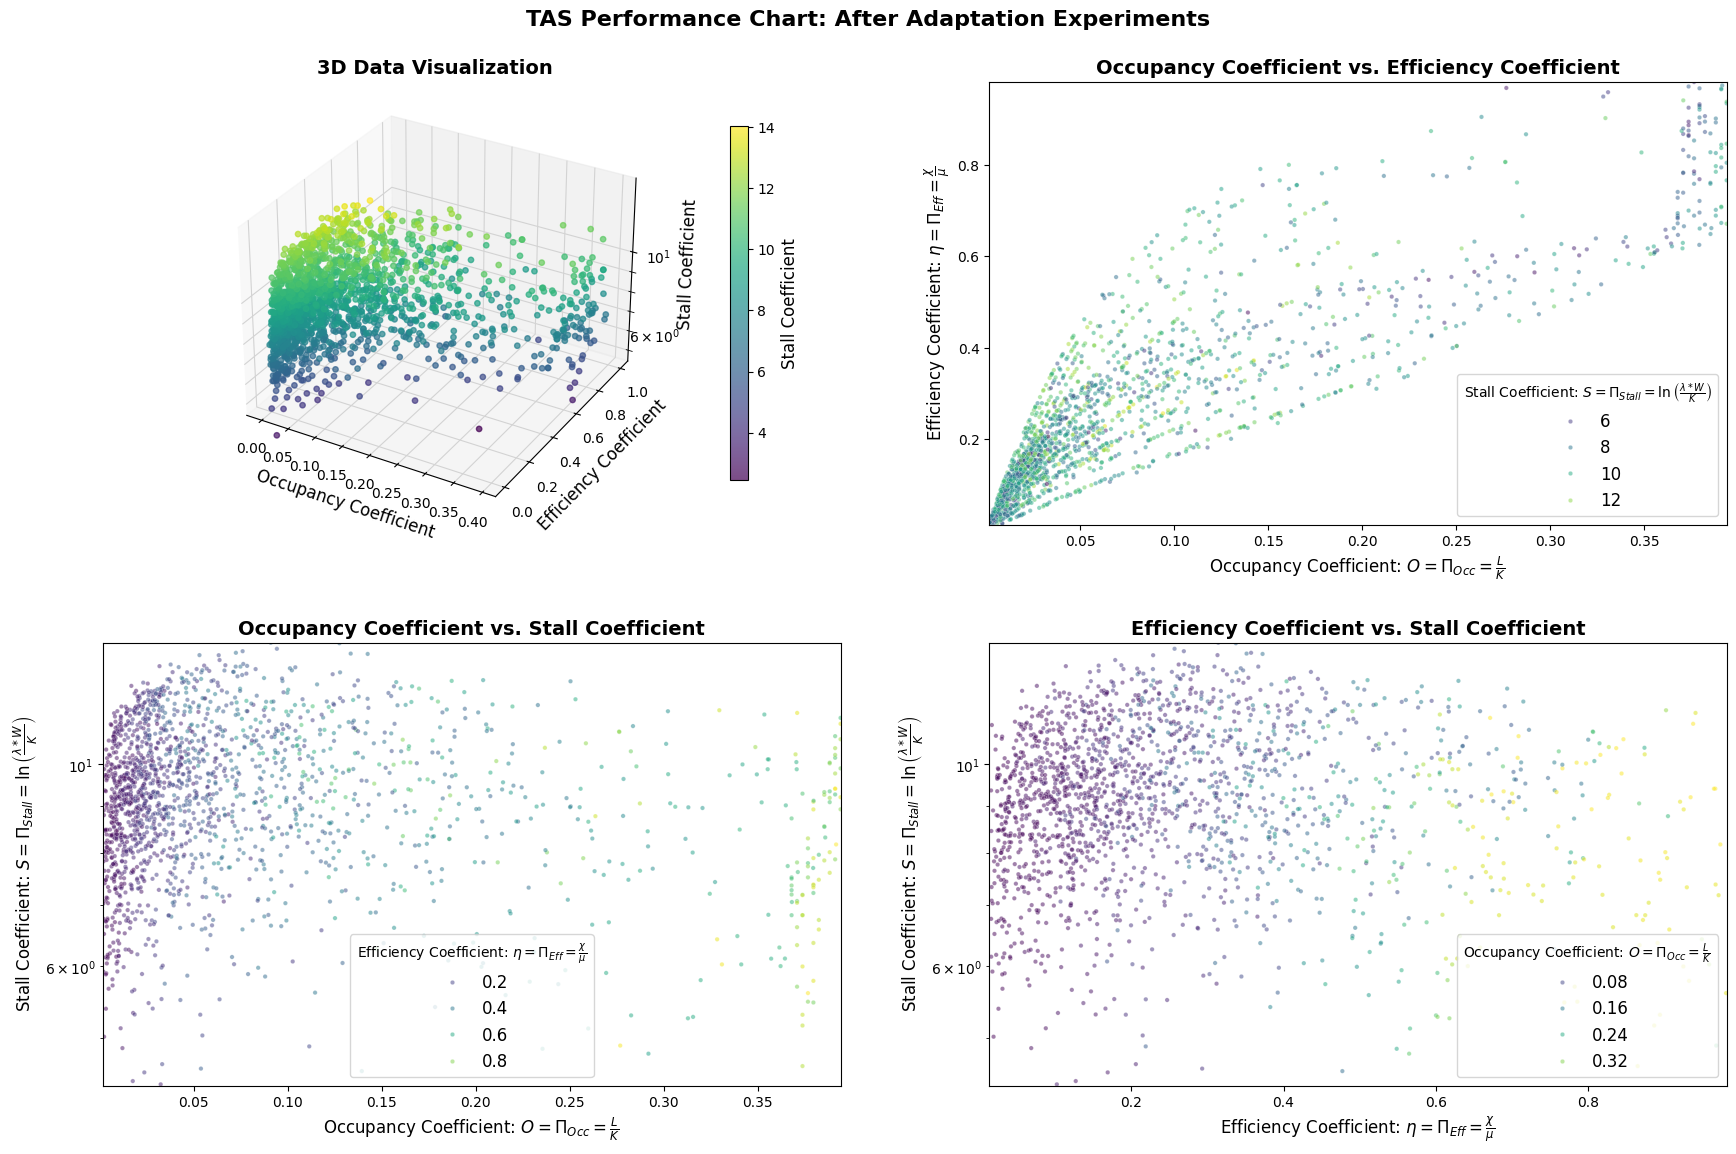

In [95]:
print("--- Charting 3D Dimensionless Coefficients ---")
metrics = opti_sys_coef[deriv_cols].columns.tolist()

# labels for the plots
labels = [
    "Occupancy Coefficient",
    "Efficiency Coefficient",
    "Stall Coefficient",
]
print(metrics)
print(labels)

# plot dimensionless experiments
title = "TAS Performance Chart: After Adaptation Experiments"
plot_experiment_coef_chart(opti_sys_coef[deriv_cols],
                           metrics,
                           labels,
                           title,
                           file_path,
                           "opti_dimensional_exp_chart.png",
                           percentile={"x": [0.005, 0.999],
                                       "y": [0.005, 0.999],
                                       "z": [0.005, 0.999], },
                           scale={"x": "linear", "y": "linear", "z": "log"},
                           limits={"x": [1e-5, 1.0],
                                   "y": [1e-5, 1.0],
                                   "z": [1.0e1, 1.0e10], },)

In [96]:
print("--- Creating Alternative Plot 2D DataFrame ---")
# create alternative plot dataframe
# reorganizing columns
plot_cols = [col for col in deriv_cols]
contour = plot_cols.pop()
plot_cols.insert(1, contour)
plot_df = pd.DataFrame(opti_sys_coef[plot_cols])

--- Creating Alternative Plot 2D DataFrame ---


In [97]:
# sorting by Occ, them by Stall, then by Eff
print(f"Sorting plot data by: {plot_cols}")
plot_df.sort_values(by=plot_cols, inplace=True)
plot_df.reset_index(drop=True, inplace=True)

Sorting plot data by: ['O=\\Pi_{Occ}=\\frac{L}{K}', 'S=\\Pi_{Stall}=\\ln\\left(\\frac{\\lambda*W}{K}\\right)', '\\eta=\\Pi_{Eff}=\\frac{\\chi}{\\mu}']


In [98]:
print("--- Charting Occupation and Congestion Coefficients ---")
# defining contour range with the efficiency coeffcient range
# aprox to 2nd decimal point
shift_point = 0.10

# min value for contour levels
min_val = plot_df[eff_coef].min() + shift_point

# max value for contour levels
max_val = plot_df[eff_coef].max()

# creating contour levels
n_contours = 10
contour_vals = np.linspace(min_val, max_val, n_contours)
contour_vals = np.round(contour_vals, 2).tolist()
contour_vals[-1] = 0.99

# printing contour levels
print(f"Contour levels from {min_val} to {max_val}: {contour_vals}")

# using contour lines at the beginning of the program
metrics = plot_df.columns.tolist()
labels = [
    "Occupation",       # "Effectiveness",
    "Stall",            # "Stall",
    "Efficiency",       # "Occupation",
]
contour_name = deriv_cols[1]
print(f"Contour levels from: {contour_name}")
print(f"No. of contour lines {len(contour_vals)}")

--- Charting Occupation and Congestion Coefficients ---
Contour levels from 0.10072525115965841 to 0.9958245600933485: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
Contour levels from: \eta=\Pi_{Eff}=\frac{\chi}{\mu}
No. of contour lines 10


In [99]:
# plot this data in regular chart
plot_df.info()
plot_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1919 entries, 0 to 1918
Data columns (total 3 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   O=\Pi_{Occ}=\frac{L}{K}                            1919 non-null   float64
 1   S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right)  1919 non-null   float64
 2   \eta=\Pi_{Eff}=\frac{\chi}{\mu}                    1919 non-null   float64
dtypes: float64(3)
memory usage: 45.1 KB


,O=\Pi_{Occ}=\frac{L}{K},S=\Pi_{Stall}=\ln\left(\frac{\lambda*W}{K}\right),\eta=\Pi_{Eff}=\frac{\chi}{\mu}
count,1919.000000,1919.000000,1919.000000
mean,0.081091,9.228316,0.265641
std,0.096084,1.761521,0.209323
min,0.000121,2.438006,0.000725
25%,0.018742,8.062364,0.111366
50%,0.042105,9.247634,0.205899
75%,0.102596,10.474603,0.363166
max,0.394006,14.044299,0.995825


--- Plotting TAS Performance Chart ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_dimensional_perf_chart.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\data\results\cs1\img\opti_dimensional_perf_chart.png


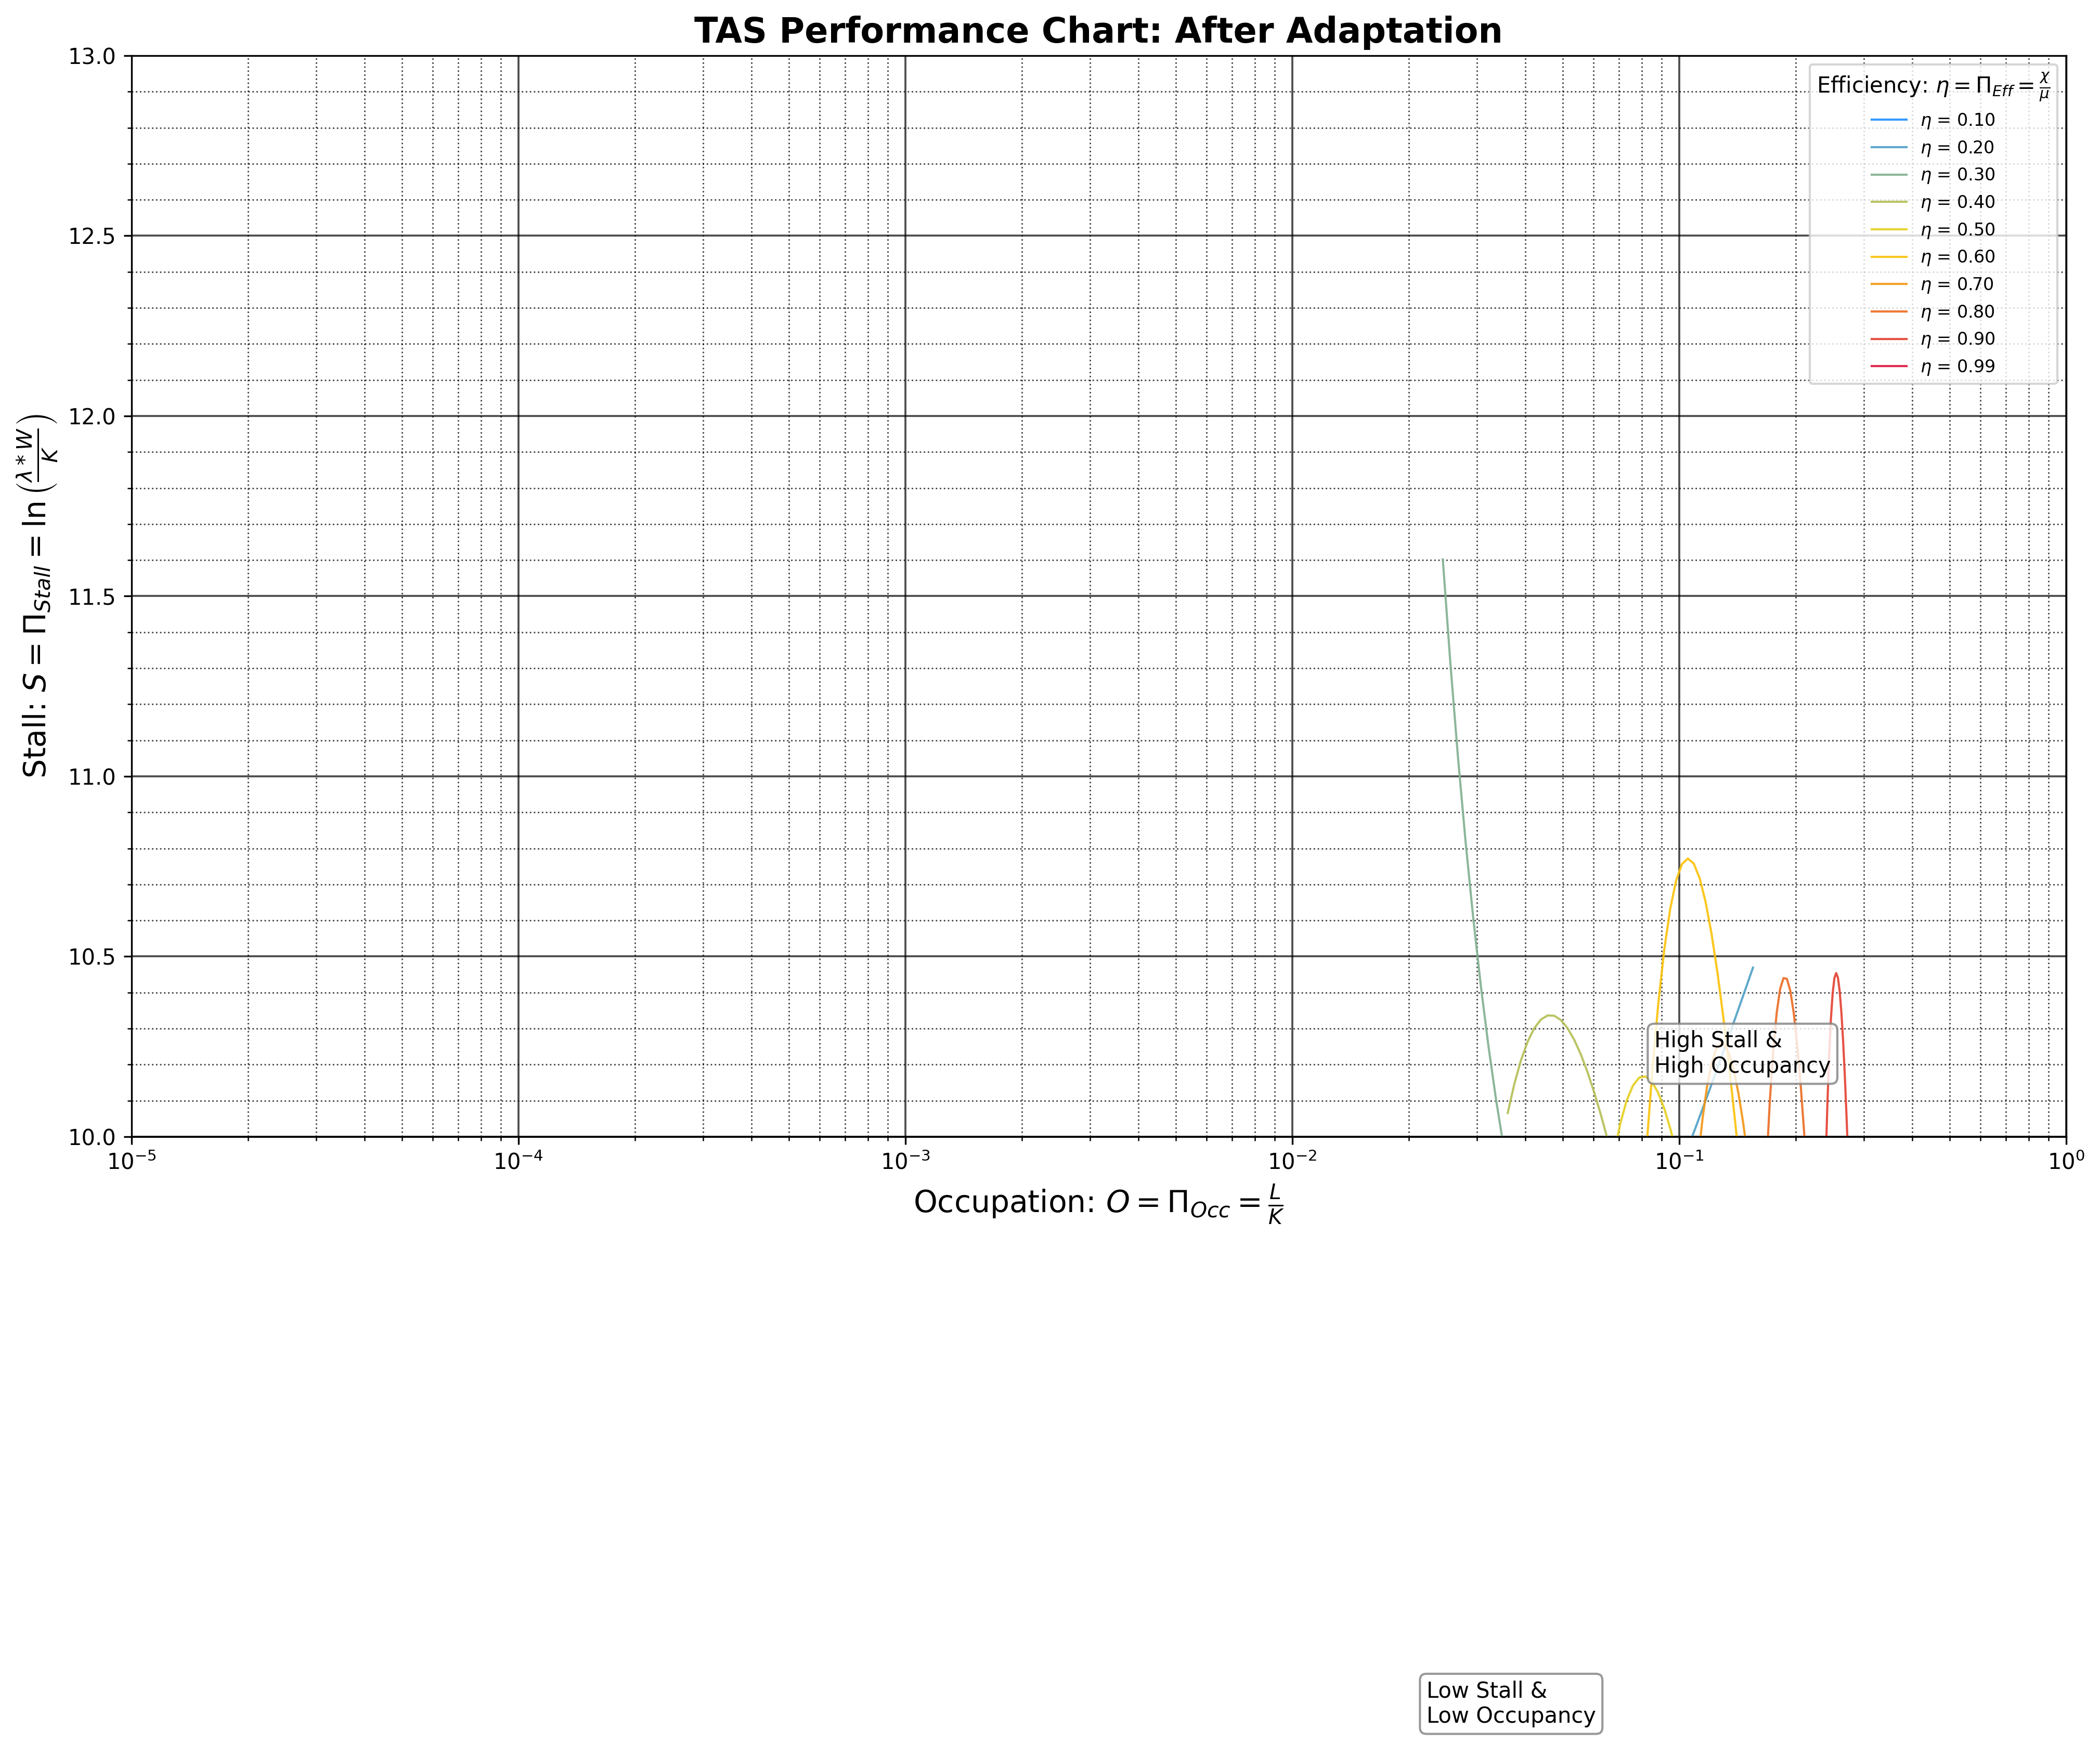

In [100]:
# plotting the queue network dimensionless chart
# selecting images folder
print("--- Plotting TAS Performance Chart ---")
file_path = os.path.join(PATH,
                         data_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"Data path: {file_path}")

# plot dimensionless system chart
title = "TAS Performance Chart: After Adaptation"
plot_performance_coef_chart(plot_df,
                            contour_name,
                            contour_vals,
                            metrics,
                            labels,
                            title,
                            file_path,
                            "opti_dimensional_perf_chart.png",
                            percentile={"x": [0.005, 0.999],
                                        "y": [0.005, 0.999]},
                            scale={"x": "log", "y": "linear"},
                            limits={"x": [1e-5, 1.0],
                                    "y": [1e1, 1.3e1]},)

In [101]:
# cleaning memory
gc.collect()

30350

## **Analysis**

### **Graph Analysis**

### **Data Analysis**

The steps are:

1) Extract and organize simulation data into a unique DataFrame.
2) Add metadata and basic statistics.
3) Save the dataframe to a CSV file.
4) Create a basic dimensionless plot (similar to Moody's chart)

## **Conclusion**

Understanding Contour Behavior in Your Queue System Chart
The contour lines in your plot represent queue length values (10, 20, 30, 40, 50), and they appear higher and closer to the Y-axis for higher values due to several important queue theory principles:

Why This Pattern Occurs
Exponential Queue Growth: In queueing theory, as system utilization (ρ = λ/μ) approaches 1.0, queue length grows exponentially rather than linearly. This fundamental property creates the compressed contour pattern you're seeing.

Dimensionless Variables Relationship: Your dimensionless plot shows that:

Small changes in the X-axis variable (first Pi coefficient) cause large changes in queue length when the system is near capacity
The Y-axis variable (second Pi coefficient) has less impact on queue length at higher utilization levels
Log-Log Scale Effect: You're using logarithmic scales on both axes, which compresses the higher values and spreads out the lower values, making this pattern more pronounced.

Queue Theory Interpretation
This pattern visualizes a critical queueing system concept: the performance cliff effect. As your system approaches saturation:

Small increases in load (moving right on X-axis) cause dramatically larger queue lengths
Improving service rate (moving up on Y-axis) provides diminishing returns once the system is near saturation
This is why the higher contour lines (40, 50) are compressed toward the right side of the chart and appear to "stack up" near the Y-axis.

Engineering Significance
This pattern in your data suggests:

Your system has a critical utilization threshold beyond which performance degrades rapidly
The "High Utilization Region" you've marked represents the danger zone where small load increases cause large queue growth
The system should be operated with sufficient margin from this threshold to maintain stable performance
This is exactly the kind of relationship a Moody-style chart should reveal - helping identify safe operating regions and performance boundaries in your system.

## **Future Work**

## **References & Sources**
<!-- TODO fix the references, links and details -->
1. [Queueing Theory](https://en.wikipedia.org/wiki/Queueing_theory)
2. [Dimensional Analysis](https://en.wikipedia.org/wiki/Dimensional_analysis)
3. [Simulation in Healthcare](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6466220/)

---

# **HASTA AKI!!!**